<a href="https://colab.research.google.com/github/antoniovfonseca/compare-time-series/blob/main/notebooks/comparisonTimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Compare two time series of maps**

---

This notebook compares two time series of raster maps, Time Series X and Time Series Y, that describe the same variable, such as the same land-cover class or the presence of water, for the same area at the same time points. Typical uses include comparing two classification methods, two versions of a data product, or a classification against reference data.

Follow Section 2 to point the notebook at your data, then run the remaining cells in order. Each section below explains what it computes and how to read the results.

### What the notebook computes

**Presence at each time point** shows how much Time Series X and Time Series Y agree or disagree that something is present, at each individual time point:
*   **Hits:** the amount both time series agree is present.
*   **False Alarms:** the extra amount Time Series Y shows that Time Series X does not, when Y is greater than X.
*   **Misses:** the extra amount Time Series X shows that Time Series Y does not, when X is greater than Y.
*   **Space Difference:** the two time series agree on the total amount present but disagree on where it is.
*   **Time Difference:** the two time series agree on the total amount and location summed across all time points but disagree on when it occurred.

**Change during each time interval** uses the same five components for gains and losses between consecutive time points, summed across all time intervals, and separately for the temporal extent using only the first and last time point. Gross change tracks gains and losses separately, so a location that both gains and loses is not cancelled out. Net change is gains minus losses.

**Where it happens on the map** shows six raster maps, pixel by pixel, where Time Series X and Time Series Y agree and where they differ, for presence and for change.

### Generated Outputs
Results are written to the `OUTPUT_PATH` folder you set in Section 2:

| Folder | Contents | Produced in |
|---|---|---|
| `tables/` | 3 CSV files with the numbers behind every chart: presence, gross change, and net change | Section 3 |
| `charts/` | 6 PNG stacked-bar charts summarizing agreement and difference for presence and change | Sections 4-5 |
| `rasters/` | 6 GeoTIFF maps, one value per pixel, for use in GIS software | Section 6 |
| `maps/` | 6 PNG previews of the same six maps, ready to view or use in a report | Section 6 |

Need the raw numbers? Check `tables/`. Need figures for a report? Use `charts/` and `maps/`. Need to overlay results with other layers in QGIS or ArcGIS? Use the GeoTIFFs in `rasters/`.


## **1. Environment Setup**

In [ ]:
# @title 1.1 Install Dependencies
# @markdown Run this cell only if you are using Google Colab
get_ipython().system('pip -q install matplotlib-scalebar matplotlib-map-utils')

In [51]:
# @title 1.2 Import Modules

# Standard Library Imports
import gc
import os
import re
from contextlib import ExitStack
from typing import Dict, List, Tuple, Union

# Third-party Data & Geospatial Imports
import numpy as np
import pandas as pd
import rasterio
from pyproj import CRS, Geod, Transformer
from rasterio.windows import Window
from tqdm.auto import tqdm

# Matplotlib & Visualization Imports
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.ticker as ticker
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap, ListedColormap, Normalize
from matplotlib.patches import FancyArrowPatch, Patch, Rectangle
from matplotlib.ticker import FuncFormatter
from matplotlib_map_utils import north_arrow
from matplotlib_scalebar.scalebar import ScaleBar

In [ ]:
# @title 1.3 Configure Google Drive
# @markdown Run this cell onlye if your data is stored on Google Drive

try:
    from google.colab import drive
except ModuleNotFoundError:
    print("Google Drive mount skipped: this notebook is running outside Google Colab.")
else:
    drive.mount("/content/drive")

## **2. Input your data**

Before running Section 2.1, prepare your two raster time series so the
notebook can find and compare them automatically.

### What you need
1. **Two folders of raster maps** - one for Time Series X, one for Time
   Series Y.
2. **One single-band raster per time point, in each folder**, saved as a
   GeoTIFF with a `.tif` extension. Time Series X and Time Series Y must
   cover the exact same time points.
3. **A consistent file name pattern per folder:** `{PREFIX}{YEAR}{SUFFIX}`.
   For example, prefix `class_`, year `1990`, and suffix `.tif` produce
   `class_1990.tif`. You set the prefix, suffix, and list of years below;
   the notebook builds the expected file names from them and, when you run
   cell 2.1, checks immediately that every file exists, listing anything
   missing before any processing starts.

### Requirements for the rasters themselves
- **Identical pixel grid across every file, in both time series:** same
  width and height is required, and the notebook stops with an error
  otherwise. Same coordinate reference system, extent, and resolution are
  strongly recommended too, even though they are not automatically checked.
  If the grids do not line up pixel-for-pixel, the comparison will be wrong
  without any warning.
- **Single band.** Only band 1 of each file is read.
- **Pixel value equals presence size**, a plain non-negative number, not a
  class code. Examples are 1 or 0 for present or absent, a probability, a
  count, or biomass. If your source is a classified map with several
  categories, first convert it to one presence raster per class you want to
  compare, with 1 where the class occurs and 0 elsewhere.
- **Whole numbers.** Pixel values are read as integers internally, so
  decimals are truncated. If fractional precision matters, such as a
  probability between 0 and 1, rescale to integers first, for example by
  multiplying by 1000 and rounding.
- **One consistent no-data value** across every file, in both time series
  and every time point, marking invalid or masked pixels. Pick an integer
  that never occurs as a real presence value. The default here is `255`.

### What you fill in below - Section 2.1
- `X_FOLDER_PATH`, `Y_FOLDER_PATH` - the two folders above.
- `OUTPUT_PATH` - where results are written. This folder is created
  automatically if it does not exist.
- `YEARS` - the time points, in chronological order, matching your file
  names.
- `TIME_LABEL_MODE` - set to `"years"` to label charts with the years
  above, or to `"index"` to label them `0, 1, 2, ...` instead. This only
  changes the chart labels.
- `NO_DATA_VALUE`, `X_FILE_PREFIX`, `Y_FILE_PREFIX`, `FILE_SUFFIX` - as
  described above.


In [53]:
# @title 2.1 Configure Your App { display-mode: "form" }
# @markdown ### 📂 Path Settings
# @markdown Folder containing the Time Series X raster files:
X_FOLDER_PATH = "/Users/antoniofonseca/Dataset/savanna/col71" #@param {type:"string"}
# @markdown Folder containing the Time Series Y raster files:
Y_FOLDER_PATH = "/Users/antoniofonseca/Dataset/savanna/col10" #@param {type:"string"}
# @markdown Output folder for tables, charts, and maps:
OUTPUT_PATH = "/Users/antoniofonseca/Assessments/compare_ts/savanna" #@param {type:"string"}

# @markdown ### 🗓️ Time Range
# @markdown Comma-separated years in chronological order:
YEARS = range(1985, 2021) #@param {type:"string"}
TIME_LABEL_MODE = "years" #@param ["years", "index"]
CUSTOM_TIME_LABELS = None

# @markdown ### 🧭 Raster Settings
# @markdown Presence here is a CONTINUOUS quantity (Pontius Jr. et al. framework),
# @markdown not a binary class. Each pixel's own numeric value IS its presence size
# @markdown on [0,+∞), so there is no PRESENCE_VALUE parameter anymore.
NO_DATA_VALUE = 255 #@param {type:"integer"}

# @markdown ### 🏷️ File Names
# @markdown Example: prefix "class_" + year 1990 + suffix ".tif" -> "class_1990.tif"
X_FILE_PREFIX = "savanna_col71_" #@param {type:"string"}
Y_FILE_PREFIX = "savanna_col10_" #@param {type:"string"}
FILE_SUFFIX = ".tif" #@param {type:"string"}

# Build the paths consumed by the assessment cells.
if isinstance(YEARS, str):
    years = [
        int(year.strip())
        for year in YEARS.split(",")
        if year.strip()
    ]
else:
    years = [int(year) for year in YEARS]
if not years:
    raise ValueError("Please provide at least one year in YEARS.")
if years != sorted(set(years)):
    raise ValueError("YEARS must be unique and in chronological order.")
if TIME_LABEL_MODE not in {"years", "index"}:
    raise ValueError("TIME_LABEL_MODE must be 'years' or 'index'.")
if CUSTOM_TIME_LABELS is not None:
    time_labels = [str(label) for label in CUSTOM_TIME_LABELS]
elif TIME_LABEL_MODE == "years":
    time_labels = [str(year) for year in years]
else:
    time_labels = [str(index) for index in range(len(years))]
if len(time_labels) != len(years):
    raise ValueError("CUSTOM_TIME_LABELS must have the same length as YEARS.")
interval_labels = [
    f"{time_labels[index]}-{time_labels[index + 1]}"
    for index in range(len(time_labels) - 1)
]

time_series_x = [
    os.path.join(X_FOLDER_PATH, f"{X_FILE_PREFIX}{year}{FILE_SUFFIX}")
    for year in years
]
time_series_y = [
    os.path.join(Y_FOLDER_PATH, f"{Y_FILE_PREFIX}{year}{FILE_SUFFIX}")
    for year in years
]

no_data_value = NO_DATA_VALUE
output_path = OUTPUT_PATH

# Validate folders and files immediately.
missing_paths = [
    path for path in [X_FOLDER_PATH, Y_FOLDER_PATH, OUTPUT_PATH]
    if not os.path.exists(path)
]
missing_files = [
    path for path in time_series_x + time_series_y
    if not os.path.isfile(path)
]

if missing_paths or missing_files:
    print("Configuration needs attention.")
    if missing_paths:
        print("Missing folders:")
        for path in missing_paths:
            print(f"  - {path}")
    if missing_files:
        print("Missing raster files:")
        for path in missing_files:
            print(f"  - {path}")
else:
    print(f"Ready to process {len(years)} years of maps.")


Ready to process 36 years of maps.


In [54]:
# @title 2.2 Prepare Multi-Timepoint Raster Processing
# @markdown This cell prepares the shared raster-processing helpers used by the
# @markdown assessment and map-generation steps. No user changes are required.
import threading
from concurrent.futures import (
    ThreadPoolExecutor,
    as_completed,
)

_thread_local_eq = threading.local()


def _get_thread_datasets_eq(
    x_paths: Tuple[str, ...],
    y_paths: Tuple[str, ...],
):
    """
    Returns (srcs_x, srcs_y) — tuples of open rasterio datasets, one per
    time point, cached per worker thread. Rasterio datasets aren't safe
    to share across threads, but each thread keeping its own open
    handles (reused across blocks/calls) is the documented safe
    pattern. Shared by both the CSV table computations (presence +
    change assessment) and the equation-map raster generation — both
    read the same T+1 X/Y time series, just aggregating differently.
    """
    key = (x_paths, y_paths)
    cache = getattr(_thread_local_eq, "datasets", None)

    if cache is None or cache["key"] != key:
        if cache is not None:
            for src in cache["srcs_x"] + cache["srcs_y"]:
                src.close()
        cache = {
            "key": key,
            "srcs_x": tuple(
                rasterio.open(p) for p in x_paths
            ),
            "srcs_y": tuple(
                rasterio.open(p) for p in y_paths
            ),
        }
        _thread_local_eq.datasets = cache

    return cache["srcs_x"], cache["srcs_y"]


def _generate_uniform_windows(
    width: int,
    height: int,
    block_width: int = 1024,
    block_height: int = 1024,
):
    """
    Fallback window generator for when the input rasters don't share
    a compatible block layout — reads all of them on the SAME grid
    instead of one file's native tiling.
    """
    for row_off in range(0, height, block_height):
        h = min(block_height, height - row_off)
        for col_off in range(0, width, block_width):
            w = min(block_width, width - col_off)
            yield Window(col_off, row_off, w, h)


def _resolve_windows_eq(srcs: List) -> List[Window]:
    """
    Picks the window strategy for reading all T+1 X and Y rasters
    together: native block layout (fast path) when every raster shares
    the same dimensions and block size; a uniform grid otherwise.
    """
    dims = {
        (s.width, s.height) for s in srcs
    }
    if len(dims) > 1:
        raise ValueError(
            f"All X and Y rasters must have matching dimensions; got {dims}."
        )

    same_blocks = len(
        {tuple(s.block_shapes) for s in srcs}
    ) == 1

    if same_blocks:
        return [
            window for _, window in srcs[0].block_windows()
        ]

    print(
        "  [warning] input rasters have different internal block "
        "layouts; reading with a uniform window grid instead of "
        "native tiling."
    )
    width, height = next(iter(dims))
    return list(
        _generate_uniform_windows(width, height)
    )


## **3. Presence and Change Components**

This section reads your rasters once and calculates every number used
later. The presence results feed Section 4, and the change results feed
Section 5. Run cell 3.2 once - it can take a while on large rasters. Its
output is the three tables listed under `tables/` above; open them
directly, for example in Excel or pandas, if you want the raw numbers in
addition to, or instead of, the charts.


In [55]:
# @title 3.1 Prepare Chart Visualization Tools
# @markdown This cell prepares the common display tools used by the charts below:
# @markdown 1. Choose readable scales and axis intervals.
# @markdown 2. Apply consistent colors and hatch patterns.
# @markdown 3. Create legends for presence, gain, and loss components.
# @markdown 4. Keep the chart style consistent across the analysis results.

def _fixed_step_yticks(
    top_value,
    target_ticks=8,
    min_ticks=3,
    max_ticks=20,
):
    """
    Builds Y-axis ticks with EQUAL intervals.

    For integer-valued maxima (e.g. small validated pixel counts like
    the toy data), searches for an EXACT divisor of the max so the
    axis ends precisely on the true value — useful when the exact
    number needs to be checkable.

    For non-integer maxima (the common case for real datasets after
    scaling to "million/billion pixels"), an exact divisor essentially
    never exists, so instead this picks the "nicest" round step
    (1/2/2.5/5/10 x 10^k) whose resulting tick count is closest to
    target_ticks, and the axis ends on the next nice multiple at or
    above the true max — the standard way charts show round gridlines.

    Parameters
    ----------
    top_value : float
        The true maximum value the axis must cover.
    target_ticks : int, optional
        Preferred number of intervals. Default is 8.
    min_ticks : int, optional
        Minimum acceptable number of intervals. Default is 3.
    max_ticks : int, optional
        Maximum acceptable number of intervals. Default is 20.

    Returns
    -------
    np.ndarray
        Tick positions from 0 up to (at least) top_value, evenly spaced.
    """
    if top_value <= 0:
        return np.array([0])

    is_intlike = abs(top_value - round(top_value)) < 1e-6

    if is_intlike:
        tv_int = round(top_value)
        divs = set()
        i = 1
        while i * i <= tv_int:
            if tv_int % i == 0:
                divs.add(i)
                divs.add(tv_int // i)
            i += 1
        candidates_n = list(divs)

        valid = [
            n for n in candidates_n
            if min_ticks <= n <= max_ticks
        ]
        if valid:
            n_intervals = min(
                valid,
                key=lambda n: abs(n - target_ticks),
            )
        elif candidates_n:
            n_intervals = min(
                candidates_n,
                key=lambda n: abs(n - max_ticks),
            )
        else:
            n_intervals = 1

        step = top_value / n_intervals
        return np.arange(
            0,
            top_value + step / 2,
            step,
        )

    # Non-integer top: pick the nicest round step whose tick count is
    # closest to target_ticks, without requiring exact divisibility.
    magnitude = 10 ** np.floor(np.log10(top_value))
    candidate_steps = sorted({
        base * magnitude * mult
        for base in (1, 2, 2.5, 5, 10)
        for mult in (0.1, 1, 10)
    })

    best_step, best_score = None, None
    for step in candidate_steps:
        n = top_value / step
        if min_ticks <= n <= max_ticks:
            score = abs(n - target_ticks)
            if best_score is None or score < best_score:
                best_step, best_score = step, n

    if best_step is None:
        best_step = top_value / target_ticks

    n_ticks_needed = int(
        np.ceil(top_value / best_step)
    )
    return np.arange(
        0,
        (n_ticks_needed + 1) * best_step,
        best_step,
    )


def _scale_dynamic(max_val):
    """
    Picks a scale factor and unit label for a value, using the same
    benchmark thresholds across every bar chart (presence, gross
    change, net change), so "hundred/thousand/million/... pixels" is
    decided consistently everywhere.

    Parameters
    ----------
    max_val : float
        The largest value the chart needs to display.

    Returns
    -------
    Tuple[float, str]
        (scale_factor, unit_name) — e.g. (1000, "thousand pixels").
        unit_name is "pixels" (no scaling) below the first threshold.
    """
    scale_benchmarks = [
        (1e12, 1e12, "trillion"),
        (1e9, 1e9, "billion"),
        (1e6, 1e6, "million"),
        (1e3, 1e3, "thousand"),
        (100, 100, "hundred"),
    ]
    for threshold, factor, label in scale_benchmarks:
        if max_val >= threshold:
            return factor, f"{label} pixels"
    return 1, "pixels"


def _apply_hatches(
    ax,
    hatches,
    edgecolor='#3a3a3a',
    linewidth=0.3,
):
    """
    Applies hatch patterns to the bar containers currently on `ax`, in
    the same order the columns were plotted. For diverging charts with
    two .plot() calls (Gain then Loss), pass `hatches * 2` so both
    halves get the matching per-category pattern. `None` entries in
    `hatches` leave that category's patches solid (untouched), since
    hatch lines need an edgecolor to render — which is why hatched
    categories get one here while solid ones don't.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes whose bar containers should be hatched.
    hatches : list
        One entry per container, in plotting order. `None` = solid.
    edgecolor : str, optional
        Edge color used to draw the hatch lines. Default '#3a3a3a'.
    linewidth : float, optional
        Edge line width for hatched patches. Default 0.3.

    Returns
    -------
    None
        The axis is updated in place.
    """
    for container, hatch in zip(ax.containers, hatches):
        if hatch:
            for patch in container.patches:
                patch.set_hatch(hatch)
                patch.set_edgecolor(edgecolor)
                patch.set_linewidth(linewidth)


def _build_diverging_legend(
    ax,
    df_gain,
    df_loss,
    metrics_order,
    colors_gain,
    colors_loss,
    hatches,
    full_order,
    loss_label_override=None,
):
    """
    Builds the Gain/Loss legend shared by the four diverging bar charts
    (gross change intervals/sum-extent, net change intervals/sum-extent):
    only categories with a non-zero value across the plotted bars are
    shown, in Fig. 2f/2h's exact top-to-bottom order.

    `loss_label_override` optionally renames Loss-side labels (e.g.
    "y>x" -> "|y|>|x|" for net change, since loss is stored as a
    negative quantity and comparing which side lost more only makes
    sense in terms of magnitude); Gain labels are always left as-is.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axes to attach the legend to.
    df_gain, df_loss : pd.DataFrame
        The (already scaled) Gain and Loss data, indexed by bar label,
        used only to check which categories are non-zero.
    metrics_order : list
        Column names in stacking order (bottom to top).
    colors_gain, colors_loss : list
        Colors aligned with metrics_order, for Gain and Loss respectively.
    hatches : list
        Hatch patterns aligned with metrics_order (None = solid).
    full_order : list of (str, str)
        (Change_Type, label) pairs in the desired top-to-bottom legend
        order, e.g. [('Gain','x>y'), ('Gain','y>x'), ..., ('Loss','Hit')].
    loss_label_override : dict, optional
        Maps a label to its Loss-side display text, e.g.
        {'y>x': '|y|>|x|', 'x>y': '|x|>|y|'}. Default None (no override).

    Returns
    -------
    matplotlib.legend.Legend
    """
    loss_label_override = loss_label_override or {}

    color_hatch_by_key = {
        ('Gain', lbl): (colors_gain[i], hatches[i])
        for i, lbl in enumerate(metrics_order)
    }
    color_hatch_by_key.update({
        ('Loss', lbl): (colors_loss[i], hatches[i])
        for i, lbl in enumerate(metrics_order)
    })

    legend_elements = [
        mpatches.Patch(
            facecolor=color_hatch_by_key[key][0],
            hatch=color_hatch_by_key[key][1],
            edgecolor='#3a3a3a' if color_hatch_by_key[key][1] else 'none',
            linewidth=0.3 if color_hatch_by_key[key][1] else 0,
            label=(
                f"{key[0]} "
                f"{loss_label_override.get(key[1], key[1]) if key[0] == 'Loss' else key[1]}"
            ),
        )
        for key in full_order
        if (
            df_gain[key[1]].sum() if key[0] == 'Gain'
            else df_loss[key[1]].abs().sum()
        ) > 0
    ]

    return ax.legend(
        handles=legend_elements,
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        frameon=False,
        fontsize=12,
    )

In [ ]:
# @title 3.2 Calculate Presence and Change Results
# @markdown This cell compares the two time series and creates three result tables:
# @markdown 1. Presence hit and differences for each time point.
# @markdown 2. Gross change components for each time interval.
# @markdown 3. Net change components for each time interval.
# @markdown
# @markdown The tables are saved in the `tables` folder and used by the charts
# @markdown in Section 4.

def _read_and_compute_full_block(
    x_paths: Tuple[str, ...],
    y_paths: Tuple[str, ...],
    window: Window,
    no_data_val: int,
) -> Tuple[
    List[Dict[str, float]],
    List[Dict[str, float]],
    Dict[str, float],
]:
    """
    Read one portion of every map and calculate the comparison metrics
    needed for presence and change assessment.

    The same loaded data is reused for all metrics to avoid reading the
    input rasters more than necessary.

    Parameters
    ----------
    x_paths : tuple of str
        Paths to the Time Series X rasters in chronological order.
    y_paths : tuple of str
        Paths to the Time Series Y rasters in chronological order.
    window : rasterio.windows.Window
        Portion of the rasters to read.
    no_data_val : int
        Pixel value treated as invalid data.

    Returns
    -------
    (presence_per_year, interval_metrics, extent_metrics)
        Tuple containing presence metrics per time point, change metrics per
        interval, and change metrics for the full time extent.
    """
    srcs_x, srcs_y = _get_thread_datasets_eq(
        x_paths,
        y_paths,
    )
    arr_x_t = [
        s.read(1, window=window).astype(np.int64) for s in srcs_x
    ]
    arr_y_t = [
        s.read(1, window=window).astype(np.int64) for s in srcs_y
    ]
    num_times = len(arr_x_t)

    # 1. Calculate presence agreement and differences for each time point.
    presence_per_year = []
    for t in range(num_times):
        ax, ay = arr_x_t[t], arr_y_t[t]
        valid = (ax != no_data_val) & (ay != no_data_val)
        x_valid = np.where(valid, ax, 0)
        y_valid = np.where(valid, ay, 0)
        hits = np.minimum(x_valid, y_valid)
        presence_per_year.append({
            "hits_sum": float(np.sum(hits, dtype=np.float64)),
            "x_sum": float(np.sum(x_valid, dtype=np.float64)),
            "y_sum": float(np.sum(y_valid, dtype=np.float64)),
        })

    def _change_metrics(x0, x1, y0, y1):
        """
        Calculate agreement, gains, and losses between two time points.

        Parameters
        ----------
        x0, x1, y0, y1 : numpy.ndarray
            Corresponding maps at the beginning and end of an interval.

        Returns
        -------
        dict of str to float
            Aggregated agreement, gain, and loss values.
        """
        valid = (
            (x0 != no_data_val)
            & (x1 != no_data_val)
            & (y0 != no_data_val)
            & (y1 != no_data_val)
        )
        x0v = np.where(valid, x0, 0)
        x1v = np.where(valid, x1, 0)
        y0v = np.where(valid, y0, 0)
        y1v = np.where(valid, y1, 0)
        dx = x1v - x0v
        dy = y1v - y0v
        gain_x, gain_y = np.maximum(0, dx), np.maximum(0, dy)
        loss_x, loss_y = np.maximum(0, -dx), np.maximum(0, -dy)
        gh = np.minimum(gain_x, gain_y)
        lh = np.minimum(loss_x, loss_y)
        return {
            "gh": float(np.sum(gh, dtype=np.float64)),
            "gx": float(np.sum(gain_x, dtype=np.float64)),
            "gy": float(np.sum(gain_y, dtype=np.float64)),
            "lh": float(np.sum(lh, dtype=np.float64)),
            "lx": float(np.sum(loss_x, dtype=np.float64)),
            "ly": float(np.sum(loss_y, dtype=np.float64)),
        }

    # 2. Calculate gross and net change inputs for each interval.
    interval_metrics = [
        _change_metrics(
            arr_x_t[t - 1], arr_x_t[t],
            arr_y_t[t - 1], arr_y_t[t],
        )
        for t in range(1, num_times)
    ]

    # 3. Calculate change across the complete time range.
    extent_metrics = _change_metrics(
        arr_x_t[0], arr_x_t[-1],
        arr_y_t[0], arr_y_t[-1],
    )

    return presence_per_year, interval_metrics, extent_metrics


def calculate_full_assessment(
    ts_x_paths: List[str],
    ts_y_paths: List[str],
    no_data_val: int = 255,
    presence_output_csv: str = "presence_assessment_metrics.csv",
    gross_output_csv: str = "gross_change_components.csv",
    net_output_csv: str = "net_change_components.csv",
    max_workers: int = 8,
    time_labels: list[str] | None = None,
    interval_labels: list[str] | None = None,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Executes Presence Assessment, Gross Change Assessment, and Net
    Change Assessment together, reading each time-point raster ONLY
    ONCE per spatial block — instead of three separate passes (or, for
    change assessment alone, each middle time point read twice).

    Parameters
    ----------
    ts_x_paths, ts_y_paths : List[str]
        Paths to Time Series X and Y (same length, chronological order).
    no_data_val : int, optional
        Value for invalid pixels. Default is 255.
    presence_output_csv, gross_output_csv, net_output_csv : str, optional
        Output CSV paths for the three result tables.
    max_workers : int, optional
        Threads used to read/process raster blocks in parallel.

    Returns
    -------
    Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]
        (presence_df, gross_change_df, net_change_df)
    """
    num_times = len(ts_x_paths)
    num_intervals = num_times - 1
    time_labels = time_labels or [str(index) for index in range(num_times)]
    interval_labels = interval_labels or [
        f"{time_labels[index]}-{time_labels[index + 1]}"
        for index in range(num_intervals)
    ]
    if len(time_labels) != num_times:
        raise ValueError("time_labels must match the number of time points.")
    if len(interval_labels) != num_intervals:
        raise ValueError("interval_labels must match the number of intervals.")

    x_paths_t = tuple(ts_x_paths)
    y_paths_t = tuple(ts_y_paths)

    # 1. Prepare the input maps for processing.
    with ExitStack() as stack:
        srcs_x = [
            stack.enter_context(rasterio.open(p)) for p in ts_x_paths
        ]
        srcs_y = [
            stack.enter_context(rasterio.open(p)) for p in ts_y_paths
        ]
        windows = _resolve_windows_eq(srcs_x + srcs_y)

    # 2. Process the maps and collect the comparison results.
    presence_year_acc = [
        {"hits_sum": 0.0, "x_sum": 0.0, "y_sum": 0.0}
        for _ in range(num_times)
    ]
    interval_acc = [
        {"gh": 0.0, "gx": 0.0, "gy": 0.0, "lh": 0.0, "lx": 0.0, "ly": 0.0}
        for _ in range(num_intervals)
    ]
    extent_acc = {
        "gh": 0.0, "gx": 0.0, "gy": 0.0, "lh": 0.0, "lx": 0.0, "ly": 0.0
    }

    print("Starting time series analysis...")

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [
            executor.submit(
                _read_and_compute_full_block,
                x_paths_t, y_paths_t, window, no_data_val,
            )
            for window in windows
        ]
        for future in tqdm(
            as_completed(futures),
            total=len(futures),
            desc="Processing data",
        ):
            presence_per_year, interval_metrics, extent_metrics = future.result()
            for t in range(num_times):
                for k in presence_year_acc[t]:
                    presence_year_acc[t][k] += presence_per_year[t][k]
            for t in range(num_intervals):
                for k in interval_acc[t]:
                    interval_acc[t][k] += interval_metrics[t][k]
            for k in extent_acc:
                extent_acc[k] += extent_metrics[k]

    # 3. Create the presence results table.
    presence_results = []
    total_hits = total_x = total_y = total_sd = 0.0

    for t in range(num_times):
        year_label = time_labels[t]

        yr = presence_year_acc[t]
        yr_sd = min(yr["x_sum"], yr["y_sum"]) - yr["hits_sum"]
        yr_fa = max(0, yr["y_sum"] - yr["x_sum"])
        yr_miss = max(0, yr["x_sum"] - yr["y_sum"])

        presence_results.append({
            "Year": year_label,
            "Hits": yr["hits_sum"],
            "False Alarms": yr_fa,
            "Misses": yr_miss,
            "Space Difference": yr_sd,
            "Time Difference": 0,
        })

        total_hits += yr["hits_sum"]
        total_x += yr["x_sum"]
        total_y += yr["y_sum"]
        total_sd += yr_sd

    overall_time_diff = min(total_x, total_y) - total_hits - total_sd
    total_fa = max(0, total_y - total_x)
    total_miss = max(0, total_x - total_y)

    presence_results.append({
        "Year": "Total",
        "Hits": total_hits,
        "False Alarms": total_fa,
        "Misses": total_miss,
        "Space Difference": total_sd,
        "Time Difference": overall_time_diff,
    })

    df_presence = pd.DataFrame(presence_results)
    df_presence.to_csv(presence_output_csv, index=False)

    # 4. Create the gross and net change results tables.
    gross_results = []
    net_results = []

    total_gain_m = {"gh": 0.0, "gx": 0.0, "gy": 0.0}
    total_loss_m = {"lh": 0.0, "lx": 0.0, "ly": 0.0}
    acc_space_diff_gain = 0.0
    acc_space_diff_loss = 0.0

    total_qg_x, total_qg_y = 0.0, 0.0
    total_ql_x, total_ql_y = 0.0, 0.0
    qgh_total, qlh_total = 0.0, 0.0

    for t in range(num_intervals):
        label = interval_labels[t]

        int_m = interval_acc[t]

        # Calculate gross gain and loss components.
        gu = min(int_m["gx"], int_m["gy"]) - int_m["gh"]
        lu = min(int_m["lx"], int_m["ly"]) - int_m["lh"]

        gross_results.append({
            "Time_Interval": label,
            "Change_Type": "Gain",
            "Hits": int_m["gh"],
            "False Alarms": max(0, int_m["gy"] - int_m["gx"]),
            "Misses": max(0, int_m["gx"] - int_m["gy"]),
            "Space Difference": gu,
            "Time Difference": 0,
            "Alternation": 0,
        })
        gross_results.append({
            "Time_Interval": label,
            "Change_Type": "Loss",
            "Hits": int_m["lh"],
            "False Alarms": max(0, int_m["ly"] - int_m["lx"]),
            "Misses": max(0, int_m["lx"] - int_m["ly"]),
            "Space Difference": lu,
            "Time Difference": 0,
            "Alternation": 0,
        })

        for k in total_gain_m:
            total_gain_m[k] += int_m[k]
        for k in total_loss_m:
            total_loss_m[k] += int_m[k]
        acc_space_diff_gain += gu
        acc_space_diff_loss += lu

        # Calculate net gain and loss components.
        gx, gy = int_m["gx"], int_m["gy"]
        net_lx, net_ly = -int_m["lx"], -int_m["ly"]

        qg_x = max(0, gx + net_lx)
        qg_y = max(0, gy + net_ly)
        ql_x = min(0, gx + net_lx)
        ql_y = min(0, gy + net_ly)

        total_qg_x += qg_x
        total_qg_y += qg_y
        total_ql_x += ql_x
        total_ql_y += ql_y

        qgh = min(qg_x, qg_y)
        qgf = max(0, qg_y - qg_x)
        qgm = max(0, qg_x - qg_y)
        qlh = max(ql_x, ql_y)
        qlf = min(0, ql_y - ql_x)
        qlm = min(0, ql_x - ql_y)

        qgh_total += qgh
        qlh_total += qlh

        net_results.append({
            "Time_Interval": label,
            "Change_Type": "Gain",
            "Hits": qgh,
            "False Alarms": qgf,
            "Misses": qgm,
            "Space Difference": 0,
            "Time Difference": 0,
            "Alternation": 0,
        })
        net_results.append({
            "Time_Interval": label,
            "Change_Type": "Loss",
            "Hits": abs(qlh),
            "False Alarms": abs(qlf),
            "Misses": abs(qlm),
            "Space Difference": 0,
            "Time Difference": 0,
            "Alternation": 0,
        })

    # 5. Add totals across all time intervals.
    gv = (
        min(total_gain_m["gx"], total_gain_m["gy"])
        - total_gain_m["gh"]
        - acc_space_diff_gain
    )
    lv = (
        min(total_loss_m["lx"], total_loss_m["ly"])
        - total_loss_m["lh"]
        - acc_space_diff_loss
    )

    gross_results.append({
        "Time_Interval": "Total_Sum",
        "Change_Type": "Gain",
        "Hits": total_gain_m["gh"],
        "False Alarms": max(0, total_gain_m["gy"] - total_gain_m["gx"]),
        "Misses": max(0, total_gain_m["gx"] - total_gain_m["gy"]),
        "Space Difference": acc_space_diff_gain,
        "Time Difference": gv,
        "Alternation": 0,
    })
    gross_results.append({
        "Time_Interval": "Total_Sum",
        "Change_Type": "Loss",
        "Hits": total_loss_m["lh"],
        "False Alarms": max(0, total_loss_m["ly"] - total_loss_m["lx"]),
        "Misses": max(0, total_loss_m["lx"] - total_loss_m["ly"]),
        "Space Difference": acc_space_diff_loss,
        "Time Difference": lv,
        "Alternation": 0,
    })

    # Add net change totals.
    qgv = min(total_qg_x, total_qg_y) - qgh_total
    qlv = max(total_ql_x, total_ql_y) - qlh_total

    net_results.append({
        "Time_Interval": "Total_Sum",
        "Change_Type": "Gain",
        "Hits": qgh_total,
        "False Alarms": max(0, total_qg_y - total_qg_x),
        "Misses": max(0, total_qg_x - total_qg_y),
        "Space Difference": 0,
        "Time Difference": qgv,
        "Alternation": 0,
    })
    net_results.append({
        "Time_Interval": "Total_Sum",
        "Change_Type": "Loss",
        "Hits": abs(qlh_total),
        "False Alarms": max(0, abs(total_ql_y) - abs(total_ql_x)),
        "Misses": max(0, abs(total_ql_x) - abs(total_ql_y)),
        "Space Difference": 0,
        "Time Difference": abs(qlv),
        "Alternation": 0,
    })

    # Add the overall change from the first to the last time point.
    ext_m = extent_acc
    gross_results.append({
        "Time_Interval": "Temporal_Extent",
        "Change_Type": "Gain",
        "Hits": ext_m["gh"],
        "False Alarms": max(0, ext_m["gy"] - ext_m["gx"]),
        "Misses": max(0, ext_m["gx"] - ext_m["gy"]),
        "Space Difference": min(ext_m["gx"], ext_m["gy"]) - ext_m["gh"],
        "Time Difference": 0,
        "Alternation": 0,
    })
    gross_results.append({
        "Time_Interval": "Temporal_Extent",
        "Change_Type": "Loss",
        "Hits": ext_m["lh"],
        "False Alarms": max(0, ext_m["ly"] - ext_m["lx"]),
        "Misses": max(0, ext_m["lx"] - ext_m["ly"]),
        "Space Difference": min(ext_m["lx"], ext_m["ly"]) - ext_m["lh"],
        "Time Difference": 0,
        "Alternation": 0,
    })

    # Add the net change for the overall time extent.
    ext_gx, ext_gy = ext_m["gx"], ext_m["gy"]
    ext_net_lx, ext_net_ly = -ext_m["lx"], -ext_m["ly"]

    ext_qg_x = max(0, ext_gx + ext_net_lx)
    ext_qg_y = max(0, ext_gy + ext_net_ly)
    ext_ql_x = min(0, ext_gx + ext_net_lx)
    ext_ql_y = min(0, ext_gy + ext_net_ly)

    net_results.append({
        "Time_Interval": "Temporal_Extent",
        "Change_Type": "Gain",
        "Hits": min(ext_qg_x, ext_qg_y),
        "False Alarms": max(0, ext_qg_y - ext_qg_x),
        "Misses": max(0, ext_qg_x - ext_qg_y),
        "Space Difference": 0,
        "Time Difference": 0,
        "Alternation": 0,
    })
    net_results.append({
        "Time_Interval": "Temporal_Extent",
        "Change_Type": "Loss",
        "Hits": abs(max(ext_ql_x, ext_ql_y)),
        "False Alarms": abs(min(0, ext_ql_y - ext_ql_x)),
        "Misses": abs(min(0, ext_ql_x - ext_ql_y)),
        "Space Difference": 0,
        "Time Difference": 0,
        "Alternation": 0,
    })

    # 6. Finalize the gross change table.
    df_gross = pd.DataFrame(gross_results)
    metrics_cols = ["Hits", "False Alarms", "Misses", "Space Difference"]
    for c_type in ["Gain", "Loss"]:
        mask_tot = (
            (df_gross["Time_Interval"] == "Total_Sum")
            & (df_gross["Change_Type"] == c_type)
        )
        mask_ext = (
            (df_gross["Time_Interval"] == "Temporal_Extent")
            & (df_gross["Change_Type"] == c_type)
        )
        sum_tot = df_gross.loc[mask_tot, metrics_cols].sum(axis=1).values[0]
        sum_ext = df_gross.loc[mask_ext, metrics_cols].sum(axis=1).values[0]
        df_gross.loc[mask_tot, "Alternation"] = sum_tot - sum_ext
    df_gross.to_csv(gross_output_csv, index=False)

    # Finalize the net change table.
    df_net = pd.DataFrame(net_results)
    for c_type in ["Gain", "Loss"]:
        mask_tot = (
            (df_net["Time_Interval"] == "Total_Sum")
            & (df_net["Change_Type"] == c_type)
        )
        mask_ext = (
            (df_net["Time_Interval"] == "Temporal_Extent")
            & (df_net["Change_Type"] == c_type)
        )
        v_tot = df_net.loc[mask_tot, metrics_cols].sum(axis=1).values[0]
        v_ext = df_net.loc[mask_ext, metrics_cols].sum(axis=1).values[0]
        df_net.loc[mask_tot, "Alternation"] = v_tot - v_ext
    df_net.to_csv(net_output_csv, index=False)

    print("Analysis completed successfully.")

    # 7. Save the tables and report their locations.
    print(
        f"Presence CSV saved to: {presence_output_csv}\n"
        f"Gross change CSV saved to: {gross_output_csv}\n"
        f"Net change CSV saved to: {net_output_csv}\n"
    )

    return df_presence, df_gross, df_net


# Run the assessment and display the generated tables.
tables_dir = os.path.join(
    output_path,
    "tables",
)
os.makedirs(
    tables_dir,
    exist_ok=True,
)

csv_file_path = os.path.join(
    tables_dir,
    "presence_assessment_metrics.csv",
)
change_csv_path = os.path.join(
    tables_dir,
    "gross_change_components.csv",
)
net_change_csv_path = os.path.join(
    tables_dir,
    "net_change_components.csv",
)

df_presence_metrics, df_change_metrics, df_net_change = calculate_full_assessment(
    ts_x_paths=time_series_x,
    ts_y_paths=time_series_y,
    no_data_val=no_data_value,
    presence_output_csv=csv_file_path,
    gross_output_csv=change_csv_path,
    net_output_csv=net_change_csv_path,
    time_labels=time_labels,
    interval_labels=interval_labels,
)

display(df_presence_metrics)
display(df_change_metrics)
display(df_net_change)


## **4. Presence Visualization**

This section plots two charts from the presence table created in Section 3.2.

*   **4.1, per time point:** one bar per year. A bar made mostly of the
    "Hit" segment means the two time series closely agree that year. A
    large "y>x" or "x>y" segment means one time series shows more presence
    than the other. A large "Space Difference" segment means the two time
    series agree on the total amount but not on where it is.
*   **4.2, whole time series:** one bar summarizing presence across all
    time points, which also reveals "Time Difference": agreement on total
    amount and location, but not on when it occurred.


Chart successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/charts/presence_assessment_chart.png



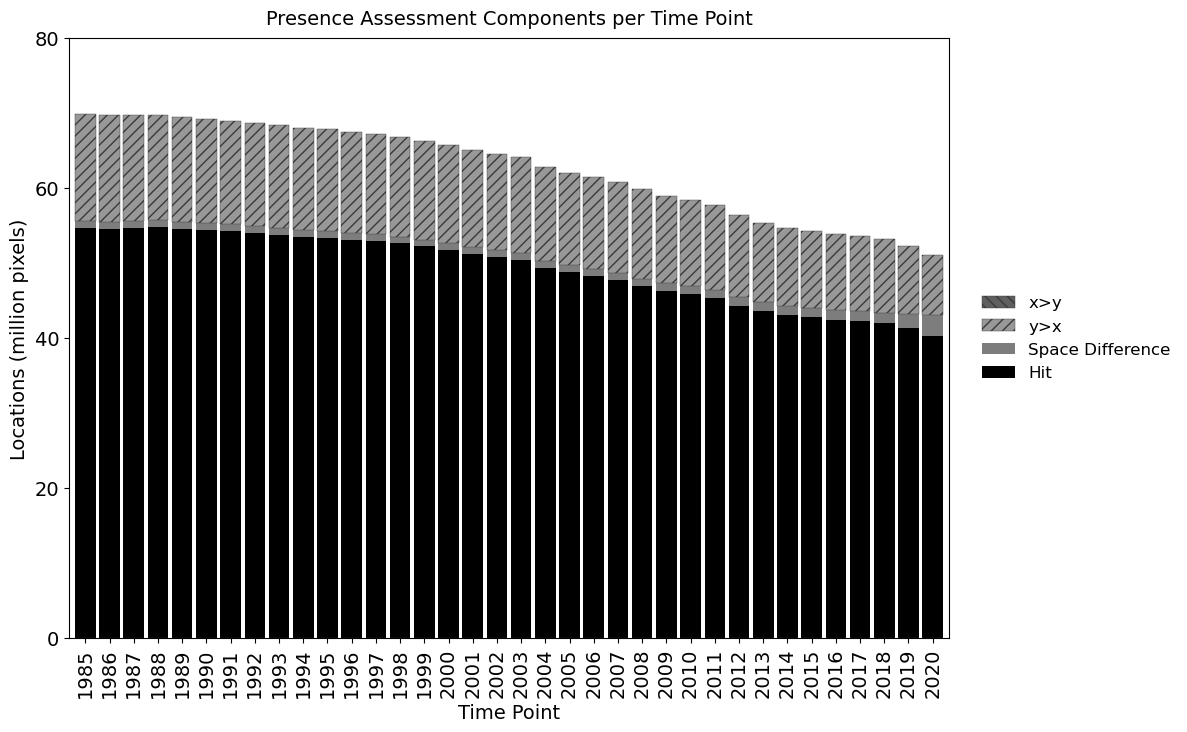

In [56]:
# @title 4.1 Plot Presence by Time Point
# @markdown This cell creates a stacked bar chart showing how the two time series
# @markdown compare at each time point.
# @markdown 1. Hits show where both time series agree on the amount of presence.
# @markdown 2. Space differences show agreement in amount but disagreement in location.
# @markdown 3. False alarms and misses show where one time series contains more presence.
# @markdown
# @markdown The chart is saved in the `charts` folder.

def plot_presence_assessment(
    csv_path: str,
    output_dir: str,
) -> None:
    """
    Create a stacked bar chart for the presence comparison at each
    time point. Each bar shows how the total presence is divided

    among agreement and difference categories.
    The chart uses grayscale fills and hatch patterns to keep the
    categories distinguishable and consistent with the other charts.
    Time Difference is not shown here because it summarizes the full
    series and is displayed in the separate sum chart (3.4).

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the presence assessment metrics.
    output_dir : str
        Directory where the 'charts' folder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Read the presence results and select the time points.
    df = pd.read_csv(csv_path)

    # Rename the table columns to the labels used in the chart legend.
    mapping = {
        'Hits':             'Hit',
        'False Alarms':     'y>x',
        'Misses':           'x>y',
        'Space Difference': 'Space Difference',
    }

    df_plot = (
        df.loc[df['Year'] != 'Total']
          .rename(columns=mapping)
          .set_index('Year')
    )

    metrics_order = [
        'Hit',
        'Space Difference',
        'y>x',
        'x>y',
    ]
    df_plot = df_plot[metrics_order]

    # 2. Scale the values so the axis remains readable for small or large datasets.
    max_val = df_plot.sum(axis=1).max()
    scale_factor, unit_name = _scale_dynamic(max_val)
    y_label = f"Locations ({unit_name})"
    df_plot /= scale_factor

    # 3. Define the visual style for each comparison category.
    colors = [
        '#000000',  # Hit - black, solid
        '#7D7D7D',  # Space Difference - mid gray, solid
        '#989898',  # y>x - light gray, hatched
        '#5F5F5F',  # x>y - dark gray, hatched
    ]
    hatches = [
        None,
        None,
        '/' * 3,
        '\\' * 3,
    ]
    hatch_by_label = dict(zip(metrics_order, hatches))

    # 4. Draw one stacked bar for each time point.
    fig, ax = plt.subplots(
        figsize=(16, 8),
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.15,
    )

    df_plot.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors,
        edgecolor='none',
        linewidth=0,
        width=0.85,
    )

    _apply_hatches(ax, hatches)

    # 5. Add evenly spaced values to the vertical axis.
    top_value = df_plot.sum(axis=1).max()
    y_ticks = _fixed_step_yticks(top_value)
    ax.set_ylim(0, top_value * 1.02)
    ax.set_yticks(y_ticks)

    # 6. Add a legend that matches the interpretation of the chart.
    handles, labels = ax.get_legend_handles_labels()
    desired_order = ['x>y', 'y>x', 'Space Difference', 'Hit']
    order_dict = {label: idx for idx, label in enumerate(labels)}
    ordered_handles, ordered_labels = zip(
        *[(handles[order_dict[lbl]], lbl) for lbl in desired_order]
    )

    leg = ax.legend(
        ordered_handles,
        ordered_labels,
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        frameon=False,
        fontsize=12,
    )

    for patch, lbl in zip(leg.get_patches(), ordered_labels):
        patch.set_linewidth(0)
        patch.set_edgecolor('none')
        if hatch_by_label.get(lbl):
            patch.set_hatch(hatch_by_label[lbl])
            patch.set_edgecolor('#3a3a3a')
            patch.set_linewidth(0.3)

    # 7. Add titles and labels that identify the comparison results.
    ax.set_title(
        'Presence Assessment Components per Time Point',
        fontsize=14,
        pad=10,
    )
    ax.set_xlabel('Time Point', fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_xticks(range(len(df_plot)))
    ax.set_xticklabels(df_plot.index.astype(str).tolist())

    # 8. Save the chart and display it in the notebook.
    charts_dir = os.path.join(output_dir, "charts")
    os.makedirs(charts_dir, exist_ok=True)
    output_file = os.path.join(charts_dir, "presence_assessment_chart.png")

    plt.savefig(output_file, dpi=300, format='png')
    print(f"Chart successfully saved to: {output_file}\n")
    plt.show()


# Run the chart using the presence results created in cell 3.2.
tables_dir = os.path.join(
    output_path,
    "tables",
)
csv_file_path = os.path.join(
    tables_dir,
    "presence_assessment_metrics.csv",
)

plot_presence_assessment(csv_file_path, output_path)


Chart successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/charts/presence_sum_chart.png



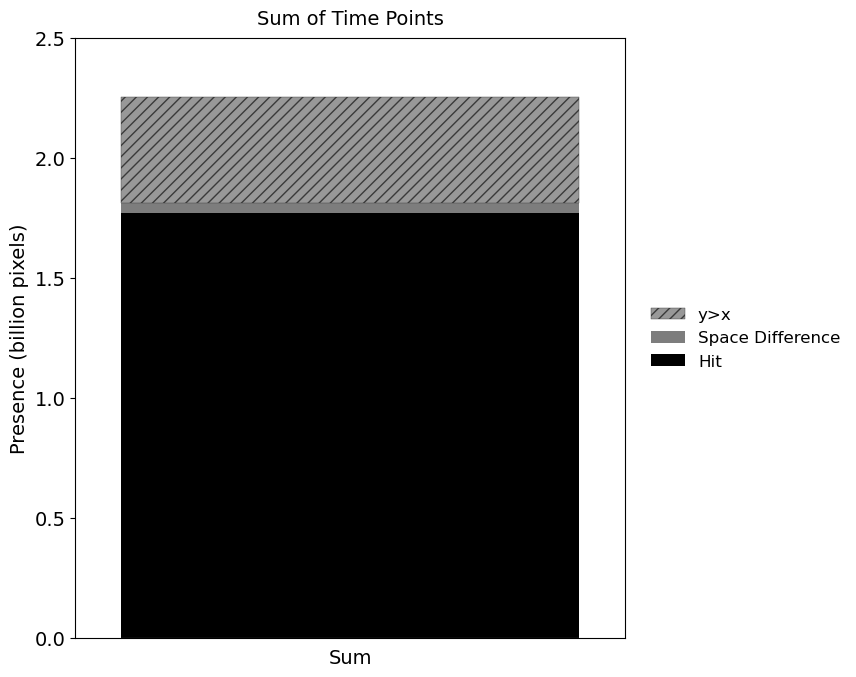

In [57]:
# @title 4.2 Plot Presence Sum
# @markdown This cell summarizes the presence comparison across the complete time
# @markdown series in one stacked bar.
# @markdown 1. Agreement and differences are combined across all time points.
# @markdown 2. Time Difference is included because it represents disagreement
# @markdown about when presence occurred.
# @markdown 3. The chart is saved in the `charts` folder for comparison with the time-point chart.

def plot_sum_chart(
    csv_path: str,
    output_dir: str,
) -> None:
    """
    Create one stacked bar that summarizes the presence comparison
    across the complete time series. The bar includes agreement,
    spatial differences, temporal differences, false alarms, and misses.

    The chart uses the same grayscale fills and hatch patterns as the
    time-point chart (3.3). Unlike that chart, this summary also includes
    Time Difference, shown as a light solid segment.
    Only categories with a non-zero value are included in the legend.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the presence assessment metrics.
    output_dir : str
        Directory where the 'charts' folder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Read the total presence results for the complete time series.
    df = pd.read_csv(csv_path)

    mapping = {
        'Hits':         'Hit',
        'False Alarms': 'y>x',
        'Misses':       'x>y',
    }

    df_plot = (
        df.loc[df['Year'] == 'Total']
          .rename(columns=mapping)
          .set_index('Year')
    )

    metrics_order = [
        'Hit',
        'Space Difference',
        'Time Difference',
        'y>x',
        'x>y',
    ]
    df_plot = df_plot[metrics_order]

    # 2. Scale the values so the summary remains easy to read.
    max_val = df_plot.sum(axis=1).max()
    scale_factor, unit_name = _scale_dynamic(max_val)
    y_label = f"Presence ({unit_name})"
    df_plot /= scale_factor

    # 3. Define the visual style for each comparison category.
    colors = [
        '#000000',  # Hit
        '#7D7D7D',  # Space Difference
        '#E4E4E4',  # Time Difference
        '#989898',  # y>x
        '#5F5F5F',  # x>y
    ]
    hatches = [
        None,
        None,
        None,
        '/' * 3,
        '\\' * 3,
    ]
    hatch_by_label = dict(zip(metrics_order, hatches))

    # 4. Draw the single stacked bar for the complete time series.
    fig, ax = plt.subplots(
        figsize=(10, 8),
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.15,
    )

    df_plot.plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors,
        edgecolor='none',
        linewidth=0,
        width=1.0,
    )

    _apply_hatches(ax, hatches)

    ax.set_xlim(-0.6, 0.6)

    # 5. Add evenly spaced values to the vertical axis.
    top_value = df_plot.sum(axis=1).max()
    y_ticks = _fixed_step_yticks(top_value)
    ax.set_ylim(0, top_value * 1.02)
    ax.set_yticks(y_ticks)

    # 6. Show only the categories that contribute to the total.
    handles, labels = ax.get_legend_handles_labels()
    full_order = ['x>y', 'y>x', 'Time Difference', 'Space Difference', 'Hit']
    desired_order = [lbl for lbl in full_order if df_plot[lbl].iloc[0] > 0]

    order_dict = {label: idx for idx, label in enumerate(labels)}
    ordered_handles, ordered_labels = zip(
        *[(handles[order_dict[lbl]], lbl) for lbl in desired_order]
    )

    leg = ax.legend(
        ordered_handles,
        ordered_labels,
        bbox_to_anchor=(1.02, 0.5),
        loc='center left',
        frameon=False,
        fontsize=12,
    )

    for patch, lbl in zip(leg.get_patches(), ordered_labels):
        patch.set_linewidth(0)
        patch.set_edgecolor('none')
        if hatch_by_label.get(lbl):
            patch.set_hatch(hatch_by_label[lbl])
            patch.set_edgecolor('#3a3a3a')
            patch.set_linewidth(0.3)

    # 7. Add labels that identify the overall presence summary.
    ax.set_title('Sum of Time Points', fontsize=14, pad=10)
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xlabel('')

    ax.set_xticklabels(['Sum'], fontsize=14, rotation=0)
    ax.tick_params(bottom=False)
    ax.tick_params(axis='y', which='major', labelsize=14)

    # 8. Save the chart and display it in the notebook.
    charts_dir = os.path.join(output_dir, "charts")
    os.makedirs(charts_dir, exist_ok=True)
    output_file = os.path.join(charts_dir, "presence_sum_chart.png")

    plt.savefig(output_file, dpi=300, format='png')
    print(f"Chart successfully saved to: {output_file}\n")
    plt.show()


# Run the summary chart using the presence results created in cell 3.2.
tables_dir = os.path.join(
    output_path,
    "tables",
)
csv_file_path = os.path.join(
    tables_dir,
    "presence_assessment_metrics.csv",
)

plot_sum_chart(csv_file_path, output_path)


## **5. Change Visualization**

This section plots four charts from the change tables created in Section
3.2. Bars above zero are gains, bars below zero are losses.

*   **5.1, gross change per time interval:** gains and losses are tracked
    separately for each time interval, so a location that both gains and
    loses in different time intervals is not cancelled out here.
*   **5.2, gross change, Sum and Extent:** "Sum" adds up every time
    interval's gross change; "Extent" compares only the first and last time
    point of the temporal extent. The difference between Sum and Extent is
    Alternation: locations that gain and lose more than once during the
    time series, which a comparison of only the first and last time point
    would miss.
*   **5.3 and 5.4, net change:** the same idea, but gains and losses in the
    same location and time interval cancel out first, since net change is
    gains minus losses. These charts use the same vertical scale as the
    gross charts so gross and net change can be compared directly.


Chart successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/charts/gross_change_intervals_chart.png



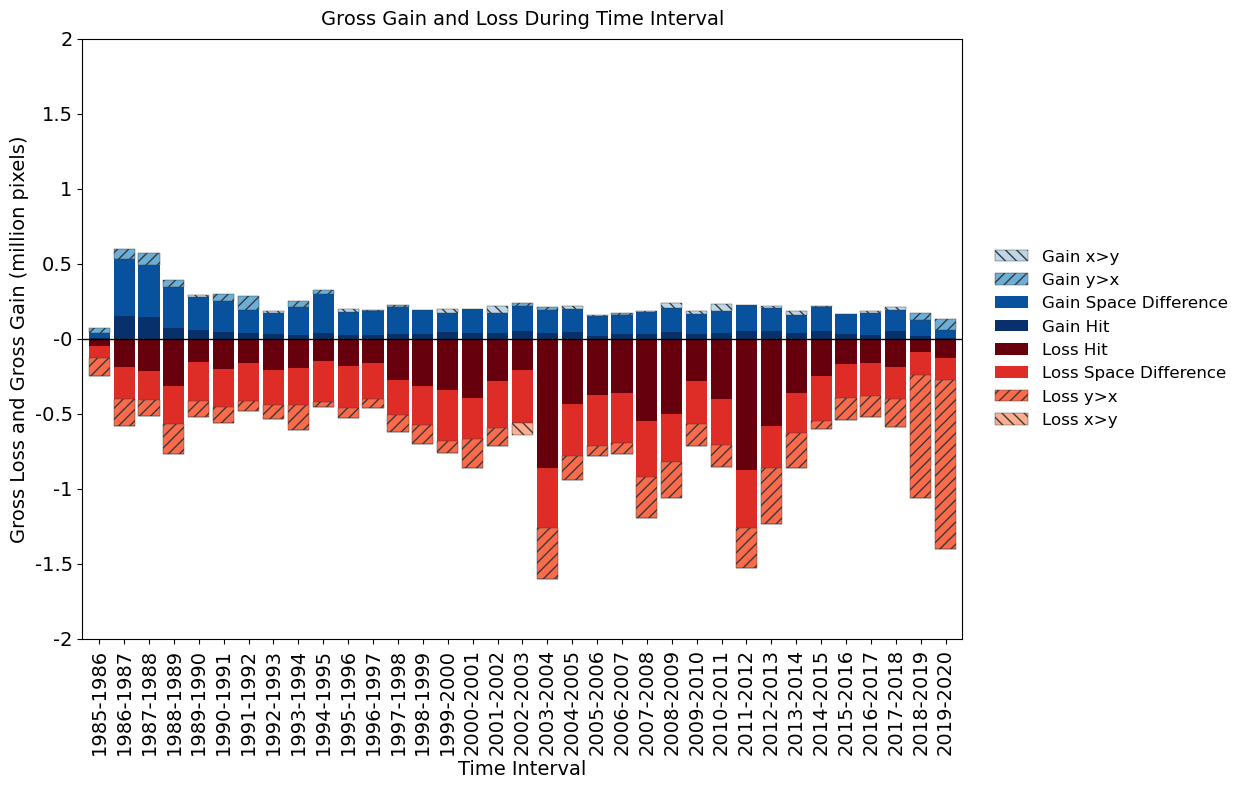

In [59]:
# @title 5.1 Plot Gross Change During Time Interval
# @markdown This cell creates a chart that compares gross change during each time interval.
# @markdown Positive bars show gross gains, and negative bars show gross losses.
# @markdown Each bar separates agreement and difference components between the two time series.
# @markdown The chart is saved in the `charts` folder.

def plot_gross_change_chart(
    csv_path: str,
    output_dir: str,
) -> None:
    """
    Create a diverging stacked bar chart that compares gross gains
    and gross losses for each time interval. Positive values represent
    gains, and negative values represent losses.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the gross change components.
    output_dir : str
        Directory where the 'charts' subfolder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Read the gross change results and select individual intervals.
    df = pd.read_csv(csv_path)

    df_filtered = df[
        ~df['Time_Interval'].isin(['Total_Sum', 'Temporal_Extent'])
    ]
    if 'Time Difference' in df_filtered.columns:
        df_filtered = df_filtered.drop(columns=['Time Difference'])
    if 'Alternation' in df_filtered.columns:
        df_filtered = df_filtered.drop(columns=['Alternation'])

    df_filtered = df_filtered.rename(columns={
        'Hits':         'Hit',
        'False Alarms': 'y>x',
        'Misses':       'x>y',
    })

    metrics_order = ['Hit', 'Space Difference', 'y>x', 'x>y']

    loss_mask = df_filtered['Change_Type'] == 'Loss'
    df_filtered.loc[loss_mask, metrics_order] *= -1

    df_gain = df_filtered[df_filtered['Change_Type'] == 'Gain'].set_index('Time_Interval')
    df_loss = df_filtered[df_filtered['Change_Type'] == 'Loss'].set_index('Time_Interval')

    # 2. Separate gains and losses, then scale the values for readability.
    max_val_gain = df_gain[metrics_order].sum(axis=1).max()
    max_val_loss = df_loss[metrics_order].abs().sum(axis=1).max()
    max_val = max(max_val_gain, max_val_loss)
    scale_factor, unit_name = _scale_dynamic(max_val)
    y_label = f"Gross Loss and Gross Gain ({unit_name})"

    df_gain[metrics_order] = df_gain[metrics_order] / scale_factor
    df_loss[metrics_order] = df_loss[metrics_order] / scale_factor
    max_val_scaled = max_val / scale_factor

    # 3. Define colors and hatch patterns for each comparison category.
    colors_gain = ['#08306b', '#08519c', '#6baed6', '#bdd7e7']
    colors_loss = ['#67000d', '#de2d26', '#fb6a4a', '#fcae91']
    hatches = [None, None, '/' * 3, '\\' * 3]

    # 4. Draw gains above zero and losses below zero.
    fig, ax = plt.subplots(
        figsize=(16, 8),
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.15,
    )

    df_gain[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_gain,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False,
    )
    df_loss[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_loss,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False,
    )

    _apply_hatches(ax, hatches + hatches)

    # 5. Use the same positive and negative scale for gains and losses.
    pos_ticks = _fixed_step_yticks(max_val_scaled)
    y_ticks = np.concatenate([-pos_ticks[::-1], pos_ticks[1:]])
    y_limit = max_val_scaled * 1.05
    ax.set_ylim(-y_limit, y_limit)
    ax.set_yticks(y_ticks)

    ax.axhline(0, color='black', linewidth=1)

    # 6. Add a legend that identifies the gain and loss components.
    full_order = [
        ('Gain', 'x>y'), ('Gain', 'y>x'), ('Gain', 'Space Difference'), ('Gain', 'Hit'),
        ('Loss', 'Hit'), ('Loss', 'Space Difference'), ('Loss', 'y>x'), ('Loss', 'x>y'),
    ]
    _build_diverging_legend(
        ax, df_gain, df_loss, metrics_order,
        colors_gain, colors_loss, hatches, full_order,
    )

    # 7. Add labels that identify the interval and the change direction.
    ax.set_title('Gross Gain and Loss During Time Interval', fontsize=14, pad=10)
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xlabel('Time Interval', fontsize=14)

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_xticks(range(len(df_gain)))
    ax.set_xticklabels(df_gain.index.tolist())

    ax.grid(False)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:g}"))

    # 8. Save the chart and display it in the notebook.
    charts_dir = os.path.join(output_dir, "charts")
    os.makedirs(charts_dir, exist_ok=True)
    output_file = os.path.join(charts_dir, "gross_change_intervals_chart.png")

    plt.savefig(output_file, dpi=300, format='png')
    print(f"Chart successfully saved to: {output_file}\n")
    plt.show()


# Run the chart using the gross change results created in Section 3.
tables_dir = os.path.join(
    output_path,
    "tables",
)
change_csv_path = os.path.join(
    tables_dir,
    "gross_change_components.csv",
)

plot_gross_change_chart(change_csv_path, output_path)


Chart successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/charts/gross_change_sum_extent_chart.png



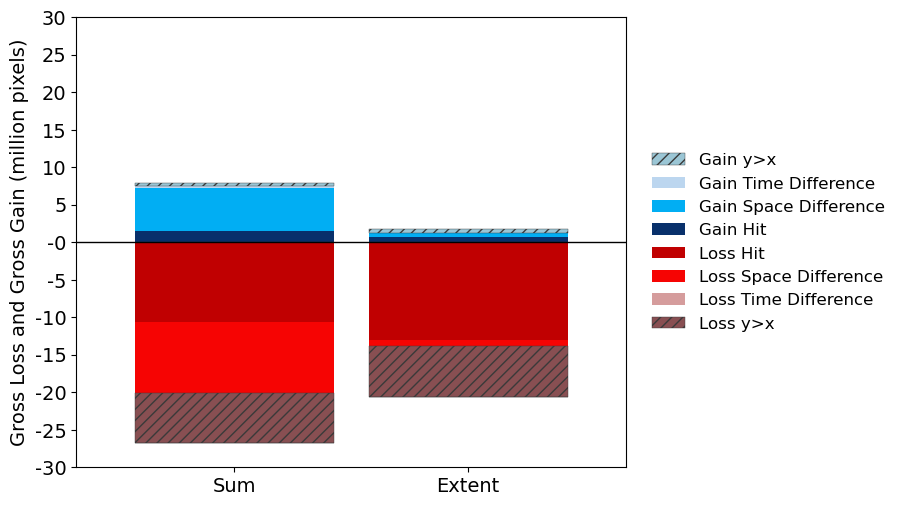

In [60]:
# @title 5.2 Plot Gross Change Sum and Extent
# @markdown This cell compares gross change from two perspectives in one chart.
# @markdown 1. The Sum bar aggregates gross gains and losses across all intervals.
# @markdown 2. The Extent bar compares the first and last time points.
# @markdown Positive bars show gains, and negative bars show losses.
# @markdown The chart is saved in the `charts` folder.

def plot_sum_and_extent_chart(
    csv_path: str,
    output_dir: str,
) -> None:
    """
    Create a diverging stacked bar chart that summarizes gross change
    across all intervals and across the full time extent. Positive values
    represent gains, and negative values represent losses.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the gross change components.
    output_dir : str
        Directory where the 'charts' subfolder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Read the gross change results for the sum and full time extent.
    df = pd.read_csv(csv_path)

    target_intervals = ['Total_Sum', 'Temporal_Extent']
    df_filtered = df[df['Time_Interval'].isin(target_intervals)].rename(columns={
        'Hits':         'Hit',
        'False Alarms': 'y>x',
        'Misses':       'x>y',
    })

    metrics_order = ['Hit', 'Space Difference', 'Time Difference', 'y>x', 'x>y']

    loss_mask = df_filtered['Change_Type'] == 'Loss'
    df_filtered.loc[loss_mask, metrics_order] *= -1

    df_gain = df_filtered[df_filtered['Change_Type'] == 'Gain'].set_index('Time_Interval')
    df_loss = df_filtered[df_filtered['Change_Type'] == 'Loss'].set_index('Time_Interval')

    df_gain = df_gain.reindex(target_intervals)
    df_loss = df_loss.reindex(target_intervals)

    rename_mapping = {'Total_Sum': 'Sum', 'Temporal_Extent': 'Extent'}
    df_gain = df_gain.rename(index=rename_mapping)
    df_loss = df_loss.rename(index=rename_mapping)

    # 2. Separate gains and losses, then scale the values for readability.
    max_val_gain = df_gain[metrics_order].sum(axis=1).max()
    max_val_loss = df_loss[metrics_order].abs().sum(axis=1).max()
    max_val = max(max_val_gain, max_val_loss)
    scale_factor, unit_name = _scale_dynamic(max_val)
    y_label = f"Gross Loss and Gross Gain ({unit_name})"

    df_gain[metrics_order] = df_gain[metrics_order] / scale_factor
    df_loss[metrics_order] = df_loss[metrics_order] / scale_factor
    max_val_scaled = max_val / scale_factor

    # 3. Define colors and hatch patterns for each comparison category.
    gain_colors_by_label = {
        'Hit':               '#08306B',
        'Space Difference':  '#01AEF3',
        'Time Difference':   '#BCD6EF',
        'y>x':                '#9BC6D5',
        'x>y':                '#61A3C3',
    }
    loss_colors_by_label = {
        'Hit':               '#C00001',
        'Space Difference':  '#F60403',
        'Time Difference':   '#D59C9C',
        'y>x':                '#884F52',
        'x>y':                '#A85050',
    }
    colors_gain = [gain_colors_by_label[lbl] for lbl in metrics_order]
    colors_loss = [loss_colors_by_label[lbl] for lbl in metrics_order]
    hatches = [None, None, None, '/' * 3, '\\' * 3]

    # 4. Draw gains above zero and losses below zero.
    fig, ax = plt.subplots(
        figsize=(10, 6),
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.15,
    )

    df_gain[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_gain,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False,
    )
    df_loss[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_loss,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False,
    )

    _apply_hatches(ax, hatches + hatches)

    # 5. Use the same positive and negative scale for both summaries.
    pos_ticks = _fixed_step_yticks(max_val_scaled)
    y_ticks = np.concatenate([-pos_ticks[::-1], pos_ticks[1:]])
    y_limit = max_val_scaled * 1.05
    ax.set_ylim(-y_limit, y_limit)
    ax.set_yticks(y_ticks)

    ax.axhline(0, color='black', linewidth=1)

    # 6. Add a legend that identifies the gain and loss components.
    full_order = [
        ('Gain', 'x>y'), ('Gain', 'y>x'), ('Gain', 'Time Difference'),
        ('Gain', 'Space Difference'), ('Gain', 'Hit'),
        ('Loss', 'Hit'), ('Loss', 'Space Difference'),
        ('Loss', 'Time Difference'), ('Loss', 'y>x'), ('Loss', 'x>y'),
    ]
    _build_diverging_legend(
        ax, df_gain, df_loss, metrics_order,
        colors_gain, colors_loss, hatches, full_order,
    )

    # 7. Add labels that distinguish the two time summaries.
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xlabel('')

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='x', labelrotation=0)

    ax.grid(False)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:g}"))

    # 8. Save the chart and display it in the notebook.
    charts_dir = os.path.join(output_dir, "charts")
    os.makedirs(charts_dir, exist_ok=True)
    output_file = os.path.join(charts_dir, "gross_change_sum_extent_chart.png")

    plt.savefig(output_file, dpi=300, format='png')
    print(f"Chart successfully saved to: {output_file}\n")
    plt.show()


# Run the chart using the gross change results created in Section 3.
tables_dir = os.path.join(
    output_path,
    "tables",
)
change_csv_path = os.path.join(
    tables_dir,
    "gross_change_components.csv",
)

plot_sum_and_extent_chart(
    csv_path=change_csv_path,
    output_dir=output_path,
)


Chart successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/charts/net_change_intervals_chart.png



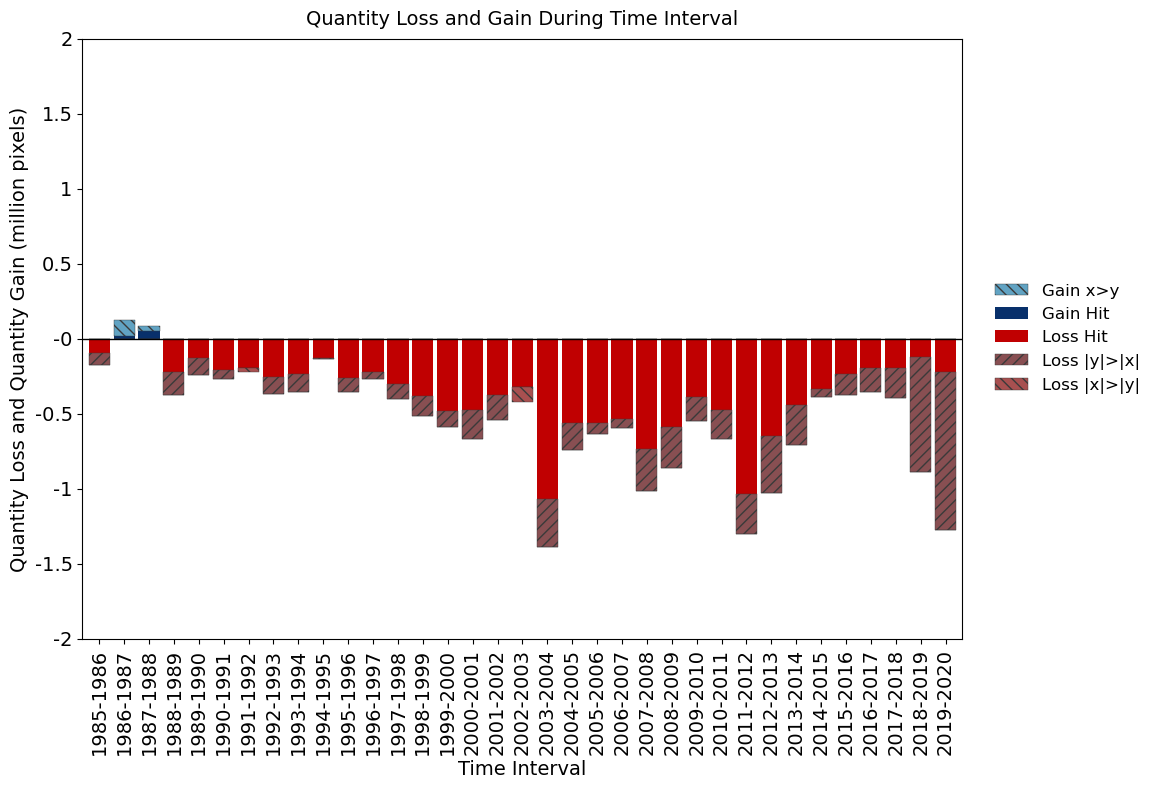

In [61]:
# @title 5.3 Plot Net Change During Time Interval
# @markdown This cell creates a chart that compares net change during each time interval.
# @markdown Positive bars show quantity gains, and negative bars show quantity losses.
# @markdown The chart uses the gross-change scale so both results can be compared directly.
# @markdown The chart is saved in the `charts` folder.

def plot_net_change_chart(
    csv_path: str,
    gross_csv_path: str,
    output_dir: str,
) -> None:
    """
    Create a diverging stacked bar chart that compares net gains
    and net losses for each time interval. The vertical scale matches
    the gross-change chart for direct visual comparison.

    Loss labels use magnitude notation to show which time series
    contributes more to the loss.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the net change components.
    gross_csv_path : str
        Path to the CSV file containing the gross change components.
    output_dir : str
        Directory where the 'charts' subfolder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Read the net change results and the gross results used for scaling.
    df = pd.read_csv(csv_path)
    df_gross = pd.read_csv(gross_csv_path)

    df_filtered = df[~df['Time_Interval'].isin(['Total_Sum', 'Temporal_Extent'])].rename(columns={
        'Hits':         'Hit',
        'False Alarms': 'y>x',
        'Misses':       'x>y',
    })
    df_gross_filtered = df_gross[
        ~df_gross['Time_Interval'].isin(
            ['Total_Sum', 'Temporal_Extent']
        )
    ].rename(columns={
        'Hits':         'Hit',
        'False Alarms': 'y>x',
        'Misses':       'x>y',
    })

    metrics_order = ['Hit', 'Space Difference', 'y>x', 'x>y']

    loss_mask = df_filtered['Change_Type'] == 'Loss'
    df_filtered.loc[loss_mask, metrics_order] *= -1

    df_gain = df_filtered[df_filtered['Change_Type'] == 'Gain'].set_index('Time_Interval')
    df_loss = df_filtered[df_filtered['Change_Type'] == 'Loss'].set_index('Time_Interval')

    # 2. Use the gross-change scale so the two charts remain comparable.
    max_val_gain_gross = (
        df_gross_filtered[
            df_gross_filtered['Change_Type'] == 'Gain'
        ][metrics_order].sum(axis=1).max()
    )
    max_val_loss_gross = (
        df_gross_filtered[
            df_gross_filtered['Change_Type'] == 'Loss'
        ][metrics_order].sum(axis=1).max()
    )
    max_val_gross = max(max_val_gain_gross, max_val_loss_gross)
    scale_factor, unit_name = _scale_dynamic(max_val_gross)
    y_label = f"Quantity Loss and Quantity Gain ({unit_name})"

    df_gain[metrics_order] = df_gain[metrics_order] / scale_factor
    df_loss[metrics_order] = df_loss[metrics_order] / scale_factor
    max_val_scaled_gross = max_val_gross / scale_factor

    # 3. Define colors and hatch patterns for each comparison category.
    gain_colors_by_label = {
        'Hit':               '#08306B',
        'Space Difference':  '#01AEF3',
        'Time Difference':   '#BCD6EF',
        'y>x':                '#9BC6D5',
        'x>y':                '#61A3C3',
    }
    loss_colors_by_label = {
        'Hit':               '#C00001',
        'Space Difference':  '#F60403',
        'Time Difference':   '#D59C9C',
        'y>x':                '#884F52',
        'x>y':                '#A85050',
    }
    colors_gain = [gain_colors_by_label[lbl] for lbl in metrics_order]
    colors_loss = [loss_colors_by_label[lbl] for lbl in metrics_order]
    hatches = [None, None, '/' * 3, '\\' * 3]

    # 4. Draw gains above zero and losses below zero.
    fig, ax = plt.subplots(
        figsize=(16, 8),
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.15,
    )

    df_gain[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_gain,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False,
    )
    df_loss[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_loss,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False,
    )

    _apply_hatches(ax, hatches + hatches)

    # 5. Apply the shared positive and negative vertical scale.
    pos_ticks = _fixed_step_yticks(max_val_scaled_gross)
    y_ticks = np.concatenate([-pos_ticks[::-1], pos_ticks[1:]])
    y_limit = max_val_scaled_gross * 1.05
    ax.set_ylim(-y_limit, y_limit)
    ax.set_yticks(y_ticks)

    ax.axhline(0, color='black', linewidth=1)

    # 6. Add a legend with magnitude labels for loss categories.
    full_order = [
        ('Gain', 'x>y'), ('Gain', 'y>x'), ('Gain', 'Space Difference'), ('Gain', 'Hit'),
        ('Loss', 'Hit'), ('Loss', 'Space Difference'), ('Loss', 'y>x'), ('Loss', 'x>y'),
    ]
    loss_label_override = {'y>x': '|y|>|x|', 'x>y': '|x|>|y|'}
    _build_diverging_legend(
        ax, df_gain, df_loss, metrics_order,
        colors_gain, colors_loss, hatches,
        full_order, loss_label_override,
    )

    # 7. Add labels that identify the interval and the change direction.
    ax.set_title('Quantity Loss and Gain During Time Interval', fontsize=14, pad=10)
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xlabel('Time Interval', fontsize=14)

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='x', labelrotation=90)
    ax.set_xticks(range(len(df_gain)))
    ax.set_xticklabels(df_gain.index.tolist())

    ax.grid(False)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:g}"))

    # 8. Save the chart and display it in the notebook.
    charts_dir = os.path.join(output_dir, "charts")
    os.makedirs(charts_dir, exist_ok=True)
    output_file = os.path.join(charts_dir, "net_change_intervals_chart.png")

    plt.savefig(output_file, dpi=300, format='png')
    print(f"Chart successfully saved to: {output_file}\n")
    plt.show()


# Run the chart using the net and gross results created in Section 3.
tables_dir = os.path.join(
    output_path,
    "tables",
)
net_change_csv_path = os.path.join(
    tables_dir,
    "net_change_components.csv",
)
change_csv_path = os.path.join(
    tables_dir,
    "gross_change_components.csv",
)

plot_net_change_chart(net_change_csv_path, change_csv_path, output_path)


Chart successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/charts/net_change_sum_extent_chart.png



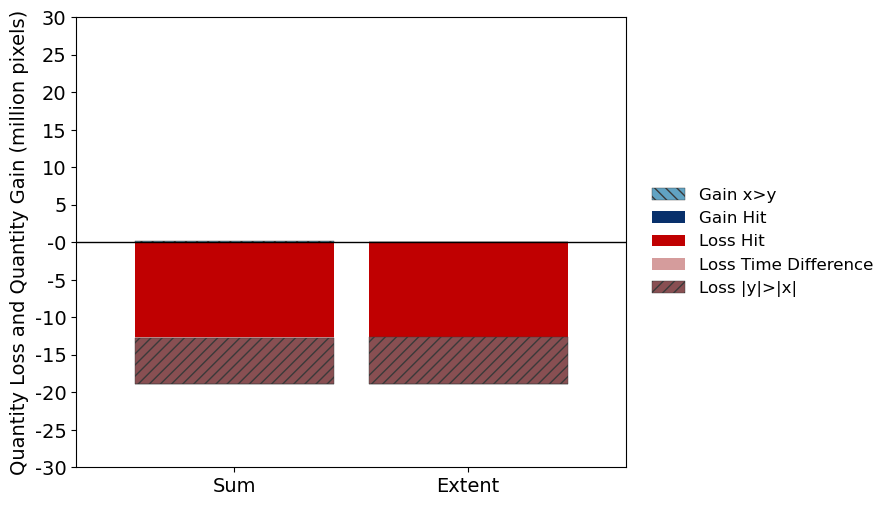

In [62]:
# @title 5.4 Plot Net Change Sum and Extent
# @markdown This cell summarizes net change from two perspectives in one chart.
# @markdown 1. The Sum bar aggregates net gains and losses across all intervals.
# @markdown 2. The Extent bar compares the first and last time points.
# @markdown Positive bars show quantity gains, and negative bars show quantity losses.
# @markdown The chart uses the gross-change scale for direct comparison.
# @markdown The chart is saved in the `charts` folder.

def plot_net_sum_and_extent_chart(
    csv_path: str,
    gross_csv_path: str,
    output_dir: str,
) -> None:
    """
    Create a diverging stacked bar chart that summarizes net change
    across all intervals and across the full time extent. Positive values
    represent gains, and negative values represent losses. The vertical
    scale matches the gross-change chart for direct visual comparison.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing the net change components.
    gross_csv_path : str
        Path to the CSV file containing the gross change components.
    output_dir : str
        Directory where the 'charts' subfolder will be created and the
        resulting plot will be saved.

    Returns
    -------
    None
    """
    # 1. Read the net and gross results for the sum and full time extent.
    df = pd.read_csv(csv_path)
    df_gross = pd.read_csv(gross_csv_path)

    target_intervals = ['Total_Sum', 'Temporal_Extent']

    df_filtered = df[df['Time_Interval'].isin(target_intervals)].rename(columns={
        'Hits':         'Hit',
        'False Alarms': 'y>x',
        'Misses':       'x>y',
    })
    df_gross_filtered = df_gross[df_gross['Time_Interval'].isin(target_intervals)].rename(columns={
        'Hits':         'Hit',
        'False Alarms': 'y>x',
        'Misses':       'x>y',
    })

    metrics_order = ['Hit', 'Space Difference', 'Time Difference', 'y>x', 'x>y']

    loss_mask = df_filtered['Change_Type'] == 'Loss'
    df_filtered.loc[loss_mask, metrics_order] *= -1

    df_gain = df_filtered[df_filtered['Change_Type'] == 'Gain'].set_index('Time_Interval')
    df_loss = df_filtered[df_filtered['Change_Type'] == 'Loss'].set_index('Time_Interval')

    df_gain = df_gain.reindex(target_intervals)
    df_loss = df_loss.reindex(target_intervals)

    rename_mapping = {'Total_Sum': 'Sum', 'Temporal_Extent': 'Extent'}
    df_gain = df_gain.rename(index=rename_mapping)
    df_loss = df_loss.rename(index=rename_mapping)

    # 2. Use the gross-change scale so the two summaries remain comparable.
    max_val_gain_gross = df_gross_filtered[df_gross_filtered['Change_Type'] == 'Gain'][metrics_order].sum(axis=1).max()
    max_val_loss_gross = df_gross_filtered[df_gross_filtered['Change_Type'] == 'Loss'][metrics_order].sum(axis=1).max()
    max_val_gross = max(max_val_gain_gross, max_val_loss_gross)
    scale_factor, unit_name = _scale_dynamic(max_val_gross)
    y_label = f"Quantity Loss and Quantity Gain ({unit_name})"

    df_gain[metrics_order] = df_gain[metrics_order] / scale_factor
    df_loss[metrics_order] = df_loss[metrics_order] / scale_factor
    max_val_scaled_gross = max_val_gross / scale_factor

    # 3. Define colors and hatch patterns for each comparison category.
    gain_colors_by_label = {
        'Hit':               '#08306B',
        'Space Difference':  '#01AEF3',
        'Time Difference':   '#BCD6EF',
        'y>x':                '#9BC6D5',
        'x>y':                '#61A3C3',
    }
    loss_colors_by_label = {
        'Hit':               '#C00001',
        'Space Difference':  '#F60403',
        'Time Difference':   '#D59C9C',
        'y>x':                '#884F52',
        'x>y':                '#A85050',
    }
    colors_gain = [gain_colors_by_label[lbl] for lbl in metrics_order]
    colors_loss = [loss_colors_by_label[lbl] for lbl in metrics_order]
    hatches = [None, None, None, '/' * 3, '\\' * 3]

    # 4. Draw gains above zero and losses below zero.
    fig, ax = plt.subplots(
        figsize=(10, 6),
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.15,
    )

    df_gain[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_gain,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False,
    )
    df_loss[metrics_order].plot(
        kind='bar',
        stacked=True,
        ax=ax,
        color=colors_loss,
        edgecolor='none',
        linewidth=0,
        width=0.85,
        legend=False,
    )

    _apply_hatches(ax, hatches + hatches)

    # 5. Apply the shared positive and negative vertical scale.
    pos_ticks = _fixed_step_yticks(max_val_scaled_gross)
    y_ticks = np.concatenate([-pos_ticks[::-1], pos_ticks[1:]])
    y_limit = max_val_scaled_gross * 1.05
    ax.set_ylim(-y_limit, y_limit)
    ax.set_yticks(y_ticks)

    ax.axhline(0, color='black', linewidth=1)

    # 6. Add a legend with magnitude labels for loss categories.
    full_order = [
        ('Gain', 'x>y'), ('Gain', 'y>x'), ('Gain', 'Time Difference'),
        ('Gain', 'Space Difference'), ('Gain', 'Hit'),
        ('Loss', 'Hit'), ('Loss', 'Space Difference'),
        ('Loss', 'Time Difference'), ('Loss', 'y>x'), ('Loss', 'x>y'),
    ]
    loss_label_override = {'y>x': '|y|>|x|', 'x>y': '|x|>|y|'}
    _build_diverging_legend(
        ax, df_gain, df_loss, metrics_order,
        colors_gain, colors_loss, hatches,
        full_order, loss_label_override,
    )

    # 7. Add labels that distinguish the two time summaries.
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_xlabel('')

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.tick_params(axis='x', labelrotation=0)

    ax.grid(False)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{x:g}"))

    # 8. Save the chart and display it in the notebook.
    charts_dir = os.path.join(output_dir, "charts")
    os.makedirs(charts_dir, exist_ok=True)
    output_file = os.path.join(charts_dir, "net_change_sum_extent_chart.png")

    plt.savefig(output_file, dpi=300, format='png')
    print(f"Chart successfully saved to: {output_file}\n")
    plt.show()


# Run the chart using the net and gross results created in Section 3.
tables_dir = os.path.join(
    output_path,
    "tables",
)
net_change_csv_path = os.path.join(
    tables_dir,
    "net_change_components.csv",
)
change_csv_path = os.path.join(
    tables_dir,
    "gross_change_components.csv",
)

plot_net_sum_and_extent_chart(
    csv_path=net_change_csv_path,
    gross_csv_path=change_csv_path,
    output_dir=output_path,
)


## **6.Spatial Comparison Maps**

This section turns the presence and change comparisons into six
pixel-by-pixel maps, so you can see where agreement and difference occur
instead of only how much:

*   **Presence Hits and Change Hits:** where Time Series X and Time Series
    Y consistently agree throughout the time series.
*   **Presence Difference and Change Difference:** where one time series
    consistently shows more presence or change than the other, and which
    one.
*   **Presence Temporal Allocation and Change Absolute Difference:** where
    Time Series X and Time Series Y agree on the total amount but disagree
    on when it occurred. These highlight timing mismatches that the totals
    alone would hide.

Each map is saved as a GeoTIFF in `rasters/`, for use in GIS software, and
as a PNG in `maps/`, for quick viewing.


In [ ]:
# @title 6.1 Generate Spatial Comparison Maps
# @markdown This cell creates six maps that compare the two time series:
# @markdown 1. Agreement in presence and change.
# @markdown 2. Differences in the amount of presence or change.
# @markdown 3. Differences in the timing of presence or change.
# @markdown
# @markdown The raster maps are saved in the `rasters` folder and visualized
# @markdown in the following cells.

def _compute_equation_block(
    arr_x_t: List[np.ndarray],
    arr_y_t: List[np.ndarray],
    no_data_val: int,
) -> Dict[str, np.ndarray]:
    """
    Computes all six equation-map components (A-F) for one spatial
    block from the same set of already-read arrays, so presence (Eq.
    49-51) and change (Eq. 52-54) never require a second read pass.
    """
    valid = np.ones_like(
        arr_x_t[0],
        dtype=bool,
    )
    for ax, ay in zip(arr_x_t, arr_y_t):
        valid &= (ax != no_data_val) & (ay != no_data_val)

    # 1. Calculate presence agreement, amount differences, and timing differences.
    A = np.zeros_like(
        arr_x_t[0],
        dtype=np.int32,
    )
    B = np.zeros_like(
        arr_x_t[0],
        dtype=np.int32,
    )
    sum_abs = np.zeros_like(
        arr_x_t[0],
        dtype=np.int32,
    )
    for ax, ay in zip(arr_x_t, arr_y_t):
        A += np.minimum(ax, ay)
        diff = ay - ax
        B += diff
        sum_abs += np.abs(diff)
    C = sum_abs - np.abs(B)

    # 2. Calculate change agreement, amount differences, and timing differences.
    D = np.zeros_like(
        arr_x_t[0],
        dtype=np.int32,
    )
    abs_diff_sum = np.zeros_like(
        arr_x_t[0],
        dtype=np.int32,
    )
    x_prev, y_prev = arr_x_t[0], arr_y_t[0]
    for ax, ay in zip(arr_x_t[1:], arr_y_t[1:]):
        dx = ax - x_prev
        dy = ay - y_prev
        gain_x, gain_y = np.maximum(0, dx), np.maximum(0, dy)
        loss_x, loss_y = np.minimum(0, dx), np.minimum(0, dy)
        gh = np.minimum(gain_x, gain_y)
        lh = np.maximum(loss_x, loss_y)
        D += (gh - lh)
        abs_diff_sum += np.abs(dy - dx)
        x_prev, y_prev = ax, ay
    E = (y_prev - arr_y_t[0]) - (x_prev - arr_x_t[0])
    F = abs_diff_sum - np.abs(E)

    return {
        "A": np.where(valid, A, no_data_val).astype(np.int32),
        "B": np.where(valid, B, no_data_val).astype(np.int32),
        "C": np.where(valid, C, no_data_val).astype(np.int32),
        "D": np.where(valid, D, no_data_val).astype(np.int32),
        "E": np.where(valid, E, no_data_val).astype(np.int32),
        "F": np.where(valid, F, no_data_val).astype(np.int32),
    }


def _read_and_compute_equation_block(
    x_paths: Tuple[str, ...],
    y_paths: Tuple[str, ...],
    window: Window,
    no_data_val: int,
) -> Tuple[Window, Dict[str, np.ndarray]]:
    """Worker: reads one block from every X/Y raster (T+1 each) ONCE
    and computes all six equation components. Runs in a thread pool —
    the disk read (via GDAL) releases the GIL, so threads overlap I/O
    wait time across blocks."""
    srcs_x, srcs_y = _get_thread_datasets_eq(
        x_paths,
        y_paths,
    )

    # 3. Read each raster block as signed numbers so calculated differences
    # can correctly include negative values.
    arr_x_t = [
        s.read(1, window=window).astype(np.int32) for s in srcs_x
    ]
    arr_y_t = [
        s.read(1, window=window).astype(np.int32) for s in srcs_y
    ]

    return window, _compute_equation_block(
        arr_x_t,
        arr_y_t,
        no_data_val,
    )


def generate_equation_maps(
    ts_x_paths: List[str],
    ts_y_paths: List[str],
    output_dir: str,
    no_data_val: int = no_data_value,
    max_workers: int = 8,
) -> None:
    """
    Generates all six equation maps (A-F, Equations 49-54) in a SINGLE
    pass over the raster blocks — presence (49-51) and change (52-54)
    used to be two separate full read-throughs of the same X/Y files;
    now every time point is read once per block and reused for both.

    Block reads run in parallel across `max_workers` threads (I/O-bound
    gain, matters most once rasters reach into the millions of
    pixels); writes stay in the main thread, one per completed block,
    which is safe since each write targets its own window regardless
    of completion order.

    Output files are named to match the equation table's columns
    (eq49_presence_hit.tif, eq50_presence_difference.tif, ...,
    eq54_change_temporal_allocation.tif) instead of the old
    presence_map_*/change_map_* naming. Overviews are built for each
    output so downstream decimated reads (map plotting) stay fast
    regardless of raster size.

    Parameters
    ----------
    ts_x_paths : List[str]
        List of file paths for Time Series X.
    ts_y_paths : List[str]
        List of file paths for Time Series Y.
    output_dir : str
        Directory where the output maps will be saved.
    no_data_val : int, optional
        Pixel value indicating no data, by default no_data_value.
    max_workers : int, optional
        Number of threads used to read/process raster blocks in
        parallel. Default is 8.

    Returns
    -------
    None
    """
    maps_dir = os.path.join(
        output_dir,
        "rasters",
    )
    os.makedirs(
        maps_dir,
        exist_ok=True,
    )

    output_names = {
        "A": "eq49_presence_hit.tif",
        "B": "eq50_presence_difference.tif",
        "C": "eq51_presence_temporal_allocation.tif",
        "D": "eq52_change_hit.tif",
        "E": "eq53_change_difference.tif",
        "F": "eq54_change_temporal_allocation.tif",
    }
    paths = {
        k: os.path.join(maps_dir, v)
        for k, v in output_names.items()
    }

    x_paths_t = tuple(ts_x_paths)
    y_paths_t = tuple(ts_y_paths)

    with ExitStack() as stack:
        srcs_x = [
            stack.enter_context(rasterio.open(p)) for p in ts_x_paths
        ]
        srcs_y = [
            stack.enter_context(rasterio.open(p)) for p in ts_y_paths
        ]
        meta = srcs_x[0].meta.copy()
        windows = _resolve_windows_eq(srcs_x + srcs_y)

    meta.update({
        'dtype': rasterio.int32,
        'nodata': no_data_val,
        'compress': 'deflate',
    })

    # 4. Prepare the six output raster files and process the comparison.
    keys = ["A", "B", "C", "D", "E", "F"]

    with ExitStack() as stack:
        dsts = {
            k: stack.enter_context(
                rasterio.open(paths[k], 'w', **meta)
            )
            for k in keys
        }

        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = [
                executor.submit(
                    _read_and_compute_equation_block,
                    x_paths_t,
                    y_paths_t,
                    window,
                    no_data_val,
                )
                for window in windows
            ]

            for future in tqdm(
                as_completed(futures),
                total=len(futures),
                desc="Generating comparison maps",
            ):
                window, out = future.result()
                for k in keys:
                    dsts[k].write(out[k], 1, window=window)

        # 5. Create smaller internal previews to make later map display faster.
        raster_width, raster_height = meta['width'], meta['height']
        candidate_levels = [2, 4, 8, 16]
        valid_levels = [
            lvl for lvl in candidate_levels
            if (raster_width // lvl) >= 2 and (raster_height // lvl) >= 2
        ]

        if valid_levels:
            for k in keys:
                dsts[k].build_overviews(
                    valid_levels,
                    rasterio.enums.Resampling.nearest,
                )
                dsts[k].update_tags(
                    ns='rio_overview',
                    resampling='nearest',
                )
        else:
            print(
                f"  [note] Raster is {raster_width}x{raster_height} pixels — too "
                f"small for any overview level to be useful; skipping."
            )

    # 6. Show where the completed raster maps were saved.
    print("\nRaster maps saved to:")
    for path in paths.values():
        print(f"  - {path}")
    print("Spatial comparison raster maps saved successfully.")


# Execute the function
generate_equation_maps(
    ts_x_paths=time_series_x,
    ts_y_paths=time_series_y,
    output_dir=output_path,
    no_data_val=no_data_value,
)

In [ ]:
# @title 6.2 Prepare Map Visualization Tools
# @markdown This cell prepares the common display tools used by the six maps below:
# @markdown 1. Load and resize the raster maps for efficient visualization.
# @markdown 2. Apply colors, legends, and labels appropriate to each map.
# @markdown 3. Add coordinates, a north arrow, and a scale bar.
# @markdown 4. Save the final map images in the `maps` folder.
from functools import lru_cache

_geod_wgs84 = Geod(ellps="WGS84")


@lru_cache(
    maxsize=None,
)
def _get_crs_transformer(src_crs_wkt: str):
    """
    Return a cached transformer from the raster CRS to geographic coordinates.

    Parameters
    ----------
    src_crs_wkt : str
        Source coordinate reference system in WKT format.

    Returns
    -------
    pyproj.Transformer
        Transformer configured for the source CRS and EPSG:4326.
    """
    return Transformer.from_crs(
        src_crs_wkt,
        "EPSG:4326",
        always_xy=True,
    )


def compute_display_pixel_size_m(
    raster_path: str,
    downsample_divisor: int,
) -> float:
    """
    Compute horizontal resolution in meters per displayed pixel.

    Only reads the raster's metadata (bounds/CRS/width) — never touches
    pixel data — so this cost is O(1) regardless of raster size. Reuses
    a cached Transformer per CRS and a single shared Geod instance
    instead of rebuilding them on every call.

    Parameters
    ----------
    raster_path : str
        Path to a raster file used to derive spatial extent and CRS.
    downsample_divisor : int
        Integer factor used to downsample the raster width for display.

    Returns
    -------
    float
        Pixel size in meters for the downsampled display grid.
    """
    with rasterio.open(raster_path) as src:
        left, bottom, right, top = src.bounds
        lat_mid_src = (top + bottom) / 2.0
        src_crs_wkt = src.crs.to_wkt()
        src_width = src.width

    to_ll = _get_crs_transformer(src_crs_wkt)
    lon_l, lat_mid = to_ll.transform(
        left,
        lat_mid_src,
    )
    lon_r, _ = to_ll.transform(
        right,
        lat_mid_src,
    )

    _, _, width_m = _geod_wgs84.inv(
        lon_l,
        lat_mid,
        lon_r,
        lat_mid,
    )

    cols_disp = max(1, src_width // downsample_divisor)

    return width_m / cols_disp


def _plot_equation_map(
    output_dir: str,
    nodata_val: int,
    raster_filename: str,
    title: str,
    legend_title: str,
    output_png_name: str,
    colormap_style: str,
    max_display_dim: int = 2000
) -> None:
    """
    Loads one comparison raster, styles it according to its map type,
    adds geographic context, and saves the resulting figure.

    Parameters
    ----------
    output_dir : str
        Directory where the 'rasters' and 'maps' folders are located.
    nodata_val : int
        Pixel value indicating no data.
    raster_filename : str
        Filename of the input raster (inside output_dir/rasters).
    title : str
        Map title.
    legend_title : str
        Legend title.
    output_png_name : str
        Filename for the saved PNG (inside output_dir/maps).
    colormap_style : str
        One of "cividis_hits", "diverging_redblue", "redyellowgreen",
        "turbo_neg_black" — selects which of the four color schemes
        used for the different comparison map types.
    max_display_dim : int, optional
        Maximum dimension (width or height) in pixels for the display
        grid to optimize RAM usage. Default is 2000.

    Returns
    -------
    None
    """
    rasters_dir = os.path.join(
        output_dir,
        "rasters",
    )
    raster_path = os.path.join(
        rasters_dir,
        raster_filename,
    )

    if not os.path.exists(raster_path):
        raise FileNotFoundError(f"Raster not found: {raster_path}")

    print(f"Reading {title} map for plotting: {raster_path}")

    # 1. Load and resize the selected raster for display.
    with rasterio.open(raster_path) as src:
        scale_factor = max_display_dim / max(
            src.width,
            src.height,
        )
        if scale_factor > 1:
            scale_factor = 1.0

        out_shape = (
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        )

        print(
            f"Loading raster with downsampling factor: "
            f"{scale_factor:.2f}"
        )

        data = src.read(
            1,
            out_shape=out_shape,
            resampling=rasterio.enums.Resampling.nearest
        )


        src_crs = src.crs
        transform = src.transform
        data_masked = np.ma.masked_equal(data, nodata_val)

    pixel_size_m = compute_display_pixel_size_m(
        raster_path=raster_path,
        downsample_divisor=(
            int(1 / scale_factor)
            if scale_factor < 1
            else 1
        ),
    )

    # 2. Select colors and legend values for this map type.
    data_max = int(data_masked.max())
    data_min = int(data_masked.min())

    if colormap_style == "cividis_hits":
        # Agreement map: use a sequential color scale.
        if data_max == 0:
            data_max = 1
        original_cmap = plt.get_cmap("cividis")
        colors_list = ["#c0c0c0"] + [
            original_cmap(i) for i in np.linspace(0, 1, data_max)
        ]
        cmap = ListedColormap(colors_list)
        bounds = np.arange(0, data_max + 2)
        norm = BoundaryNorm(bounds, cmap.N)
        colors_dict = {
            i: cmap(norm(i))
            for i in range(0, data_max + 1)
        }
        present_values = np.unique(data_masked.compressed())
        legend_values = [
            v
            for v in range(0, data_max + 1)
            if v in present_values
        ]

    elif colormap_style == "diverging_redblue":
        # Difference map: use red and blue to show direction and magnitude.
        if data_max < 1:
            data_max = 1
        if data_min > -1:
            data_min = -1

        colors_dict = {0: "#c0c0c0"}
        red_cmap = plt.get_cmap("Reds")
        red_colors = red_cmap(
            np.linspace(0.2, 0.9, abs(data_min))
        )
        for i, val in enumerate(range(-1, data_min - 1, -1)):
            colors_dict[val] = red_colors[i]

        blue_cmap = plt.get_cmap("Blues")
        blue_colors = blue_cmap(
            np.linspace(0.2, 0.9, data_max)
        )
        for i, val in enumerate(range(1, data_max + 1)):
            colors_dict[val] = blue_colors[i]

        all_vals = np.arange(
            data_min,
            data_max + 1,
        )
        colors_list = [
            colors_dict.get(v, "#000000")
            for v in all_vals
        ]
        cmap = ListedColormap(colors_list)
        bounds = np.arange(data_min - 0.5, data_max + 1.5, 1)
        norm = BoundaryNorm(bounds, cmap.N)

        present_values = np.unique(data_masked.compressed())
        legend_values = sorted(present_values, reverse=True)

    elif colormap_style == "redyellowgreen":
        # Temporal allocation map: use a sequential red-yellow-green scale.
        if data_max < 1:
            data_max = 1

        colors_dict = {0: "#c0c0c0"}
        pos_cmap = LinearSegmentedColormap.from_list(
            "red_yellow_green", ["#8b0000", "#ffff00", "#90ee90"]
        )
        for i, val in enumerate(range(1, data_max + 1)):
            frac = i / (data_max - 1) if data_max > 1 else 0.5
            colors_dict[val] = pos_cmap(frac)

        colors_list = [
            colors_dict.get(v, "#000000")
            for v in range(data_max + 1)
        ]
        cmap = ListedColormap(colors_list)
        bounds = np.arange(-0.5, data_max + 1.5, 1)
        norm = BoundaryNorm(bounds, cmap.N)

        present_values = np.unique(data_masked.compressed())
        legend_values = sorted(present_values)

    elif colormap_style == "turbo_neg_black":
        # Change agreement map: distinguish positive and negative change.
        if data_max < 1:
            data_max = 1
        if data_min > 0:
            data_min = 0

        colors_dict = {0: "#c0c0c0"}
        positive_cmap = plt.get_cmap("turbo_r")
        for val in range(1, data_max + 1):
            if data_max <= 1:
                fraction = 0.0
            elif val == 1:
                fraction = 0.0
            elif val == 2:
                fraction = 0.35
            else:
                fraction = 0.35 + 0.65 * (val - 2) / (data_max - 2)
            colors_dict[val] = positive_cmap(fraction)

        if data_min < 0:
            for val in range(data_min, 0):
                colors_dict[val] = "#000000"

        all_vals = np.arange(data_min, data_max + 1)
        colors_list = [
            colors_dict.get(v, "#000000")
            for v in all_vals
        ]
        cmap = ListedColormap(colors_list)
        bounds = np.arange(data_min - 0.5, data_max + 1.5, 1)
        norm = BoundaryNorm(bounds, cmap.N)

        present_values = np.unique(data_masked.compressed())
        legend_values = sorted(present_values)

    else:
        raise ValueError(f"Unknown colormap_style: {colormap_style}")

    # 3. Draw the raster, legend, and map title.
    fig, ax = plt.subplots(
        figsize=(8, 5),
        dpi=300,
    )
    fig.subplots_adjust(
        left=0.1,
        right=0.65,
        top=0.90,
        bottom=0.05,
    )

    ax.imshow(data_masked, cmap=cmap, norm=norm, interpolation="nearest")

    legend_elements = [
        Patch(
            facecolor=colors_dict.get(
                val,
                "#000",
            ),
            edgecolor="none",
            label=str(val),
        ) for val in legend_values
    ]

    legend_columns = max(
        1,
        min(4, int(np.ceil(len(legend_values) / 10))),
    )

    ax.legend(
        handles=legend_elements,
        title=legend_title,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
        fontsize=7,
        title_fontsize=9,
        ncol=legend_columns,
        columnspacing=0.8,
        labelspacing=0.4,
        handletextpad=0.4,
        alignment="left",
    )

    # 4. Add geographic context with a scale bar and north arrow.
    scalebar = ScaleBar(
        pixel_size_m,
        units="m",
        length_fraction=0.35,
        location="lower right",
        box_alpha=0.0,
    )
    ax.add_artist(scalebar)

    north_arrow(
        ax,
        location="upper right",
        shadow=False,
        scale=0.3,
        rotation={
            "degrees": None,
            "crs": src_crs,
            "reference": "center",
        },
    )

    # 5. Add geographic coordinates to the axes.
    ax.set_title(
        title,
        fontsize=18,
        pad=5,
    )
    ax.set_aspect("equal")

    to_latlon = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True,
    )
    height, width = data.shape

    def format_lon(x, pos):
        """
        Format an axis position as longitude in decimal degrees.

        Parameters
        ----------
        x : float
            Display-grid column position.
        pos : int
            Matplotlib tick position index.

        Returns
        -------
        str
            Longitude label with a degree symbol.
        """
        x = np.clip(x, 0, width - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, height // 2, x)
        lon, _ = to_latlon.transform(x_proj, y_proj)
        return f"{lon:.1f}°"

    def format_lat(y, pos):
        """
        Format an axis position as latitude in decimal degrees.

        Parameters
        ----------
        y : float
            Display-grid row position.
        pos : int
            Matplotlib tick position index.

        Returns
        -------
        str
            Latitude label with a degree symbol.
        """
        y = np.clip(y, 0, height - 1)
        x_proj, y_proj = rasterio.transform.xy(transform, y, width // 2)
        _, lat = to_latlon.transform(x_proj, y_proj)
        return f"{lat:.1f}°"

    ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(FuncFormatter(format_lat))
    ax.xaxis.set_major_locator(
        mticker.MaxNLocator(nbins=4)
    )
    ax.yaxis.set_major_locator(
        mticker.MaxNLocator(nbins=6)
    )
    ax.tick_params(axis="both", labelsize=7, pad=4)
    plt.setp(ax.get_yticklabels(), rotation=90, va="center")

    # 6. Save the image and release temporary data.
    maps_dir = os.path.join(
        output_dir,
        "maps",
    )
    os.makedirs(
        maps_dir,
        exist_ok=True,
    )
    output_figure_path = os.path.join(
        maps_dir,
        output_png_name,
    )

    plt.savefig(output_figure_path, dpi=300, format="png")
    plt.show()

    print(
        f"Map successfully saved to: {output_figure_path}"
    )

    del data
    del data_masked
    gc.collect()

Reading Presence Hits map for plotting: /Users/antoniofonseca/Assessments/compare_ts/savanna/rasters/eq49_presence_hit.tif
Loading raster with downsampling factor: 0.10


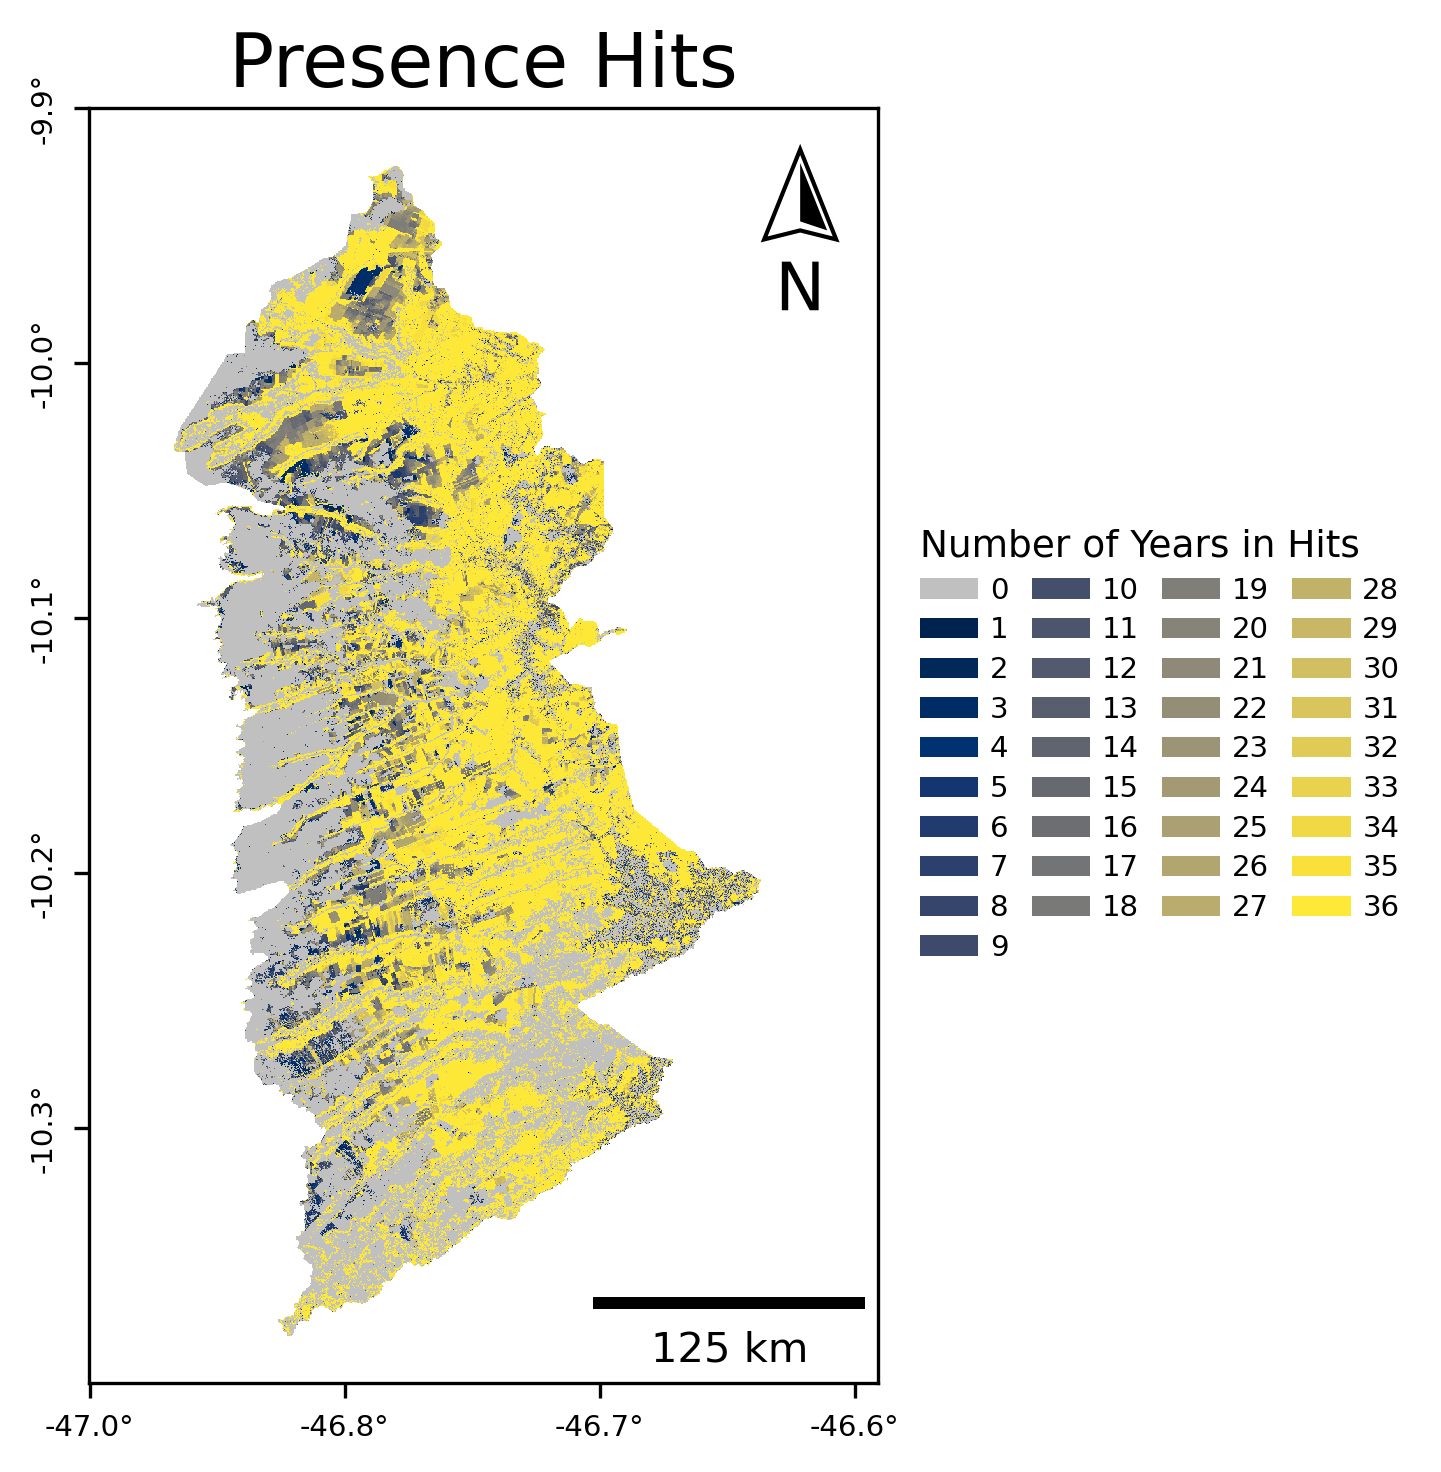

Map successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/maps/map_presence_hits.png


In [64]:
# @title 6.3 Plot Presence Hits
_plot_equation_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="eq49_presence_hit.tif",
    title="Presence Hits",
    legend_title="Number of Years in Hits",
    output_png_name="map_presence_hits.png",
    colormap_style="cividis_hits",
)


Reading Presence Difference map for plotting: /Users/antoniofonseca/Assessments/compare_ts/savanna/rasters/eq50_presence_difference.tif
Loading raster with downsampling factor: 0.10


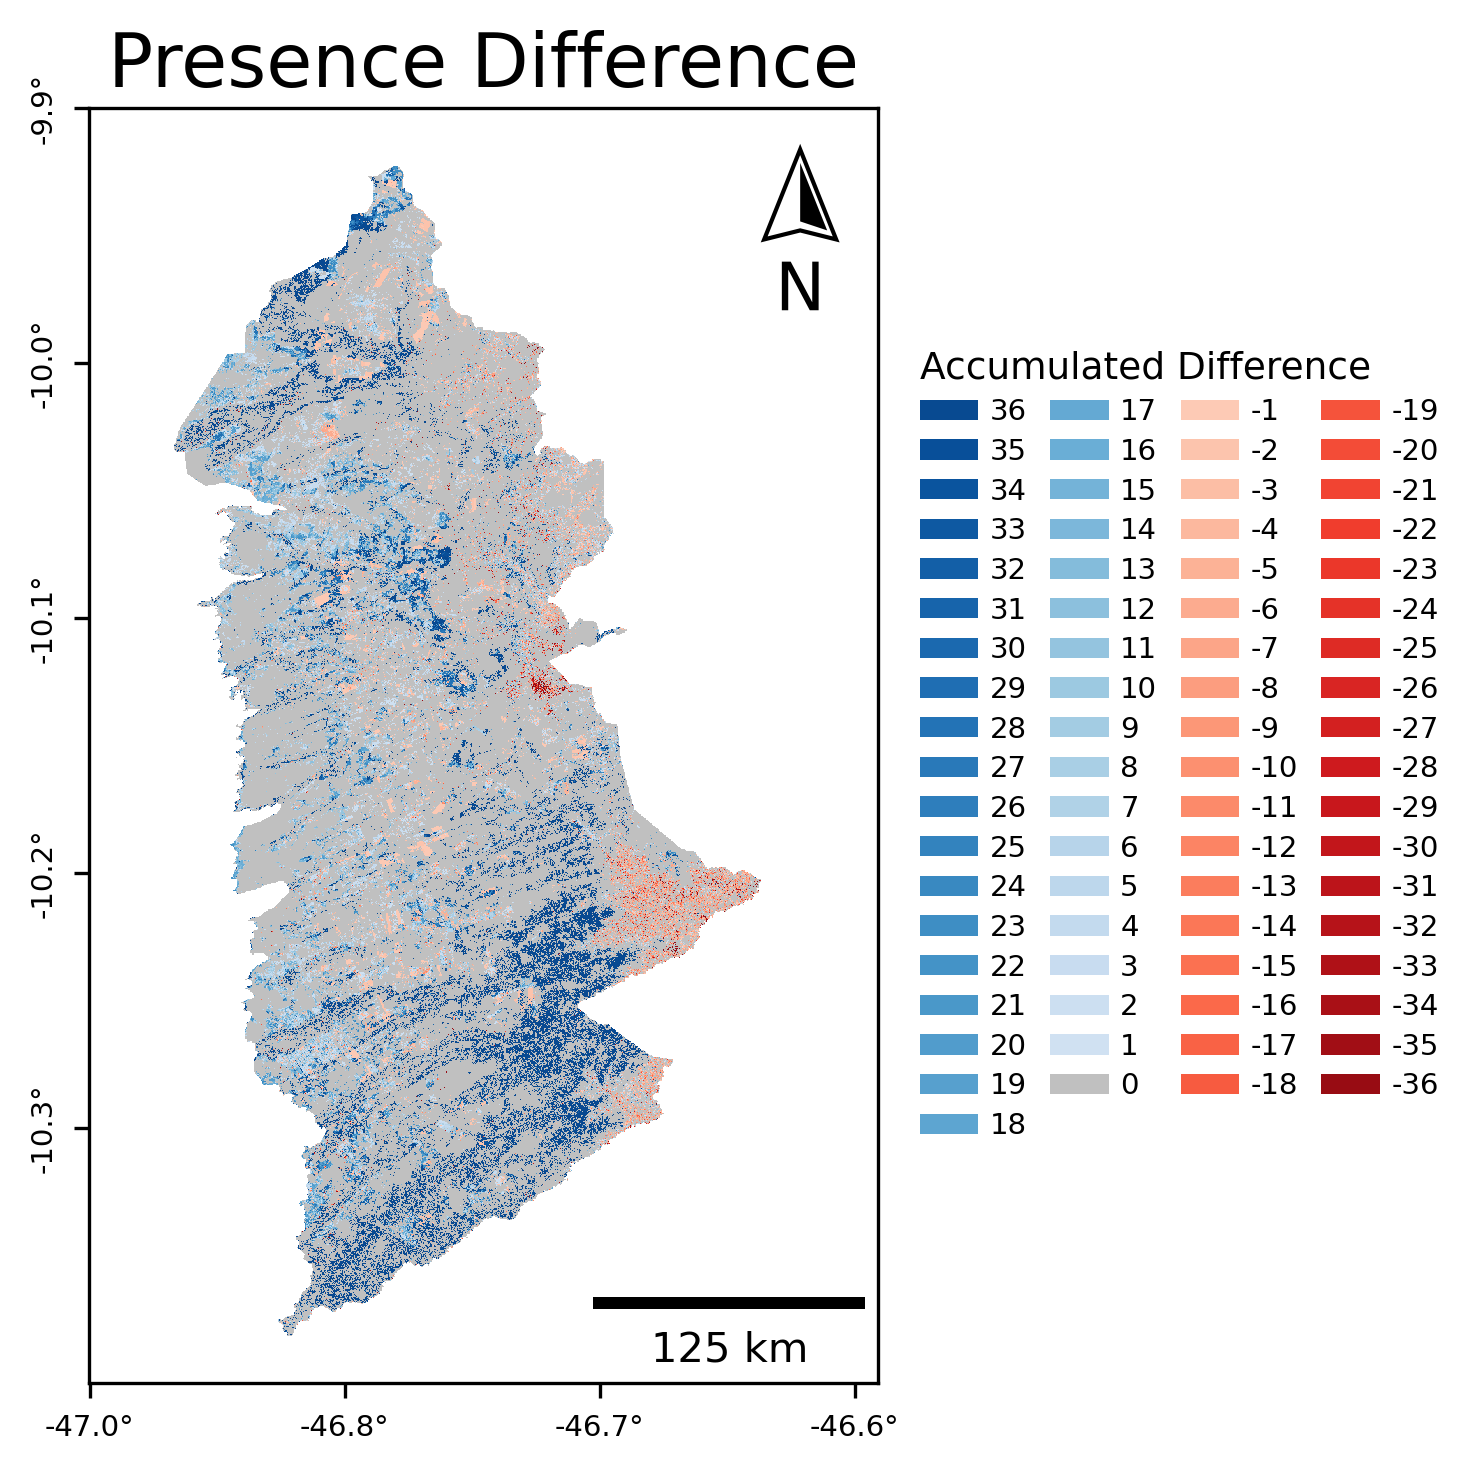

Map successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/maps/map_presence_difference.png


In [65]:
# @title 6.4 Plot Presence Difference
_plot_equation_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="eq50_presence_difference.tif",
    title="Presence Difference",
    legend_title="Accumulated Difference",
    output_png_name="map_presence_difference.png",
    colormap_style="diverging_redblue",
)


Reading Temporal Allocation Difference map for plotting: /Users/antoniofonseca/Assessments/compare_ts/savanna/rasters/eq51_presence_temporal_allocation.tif
Loading raster with downsampling factor: 0.10


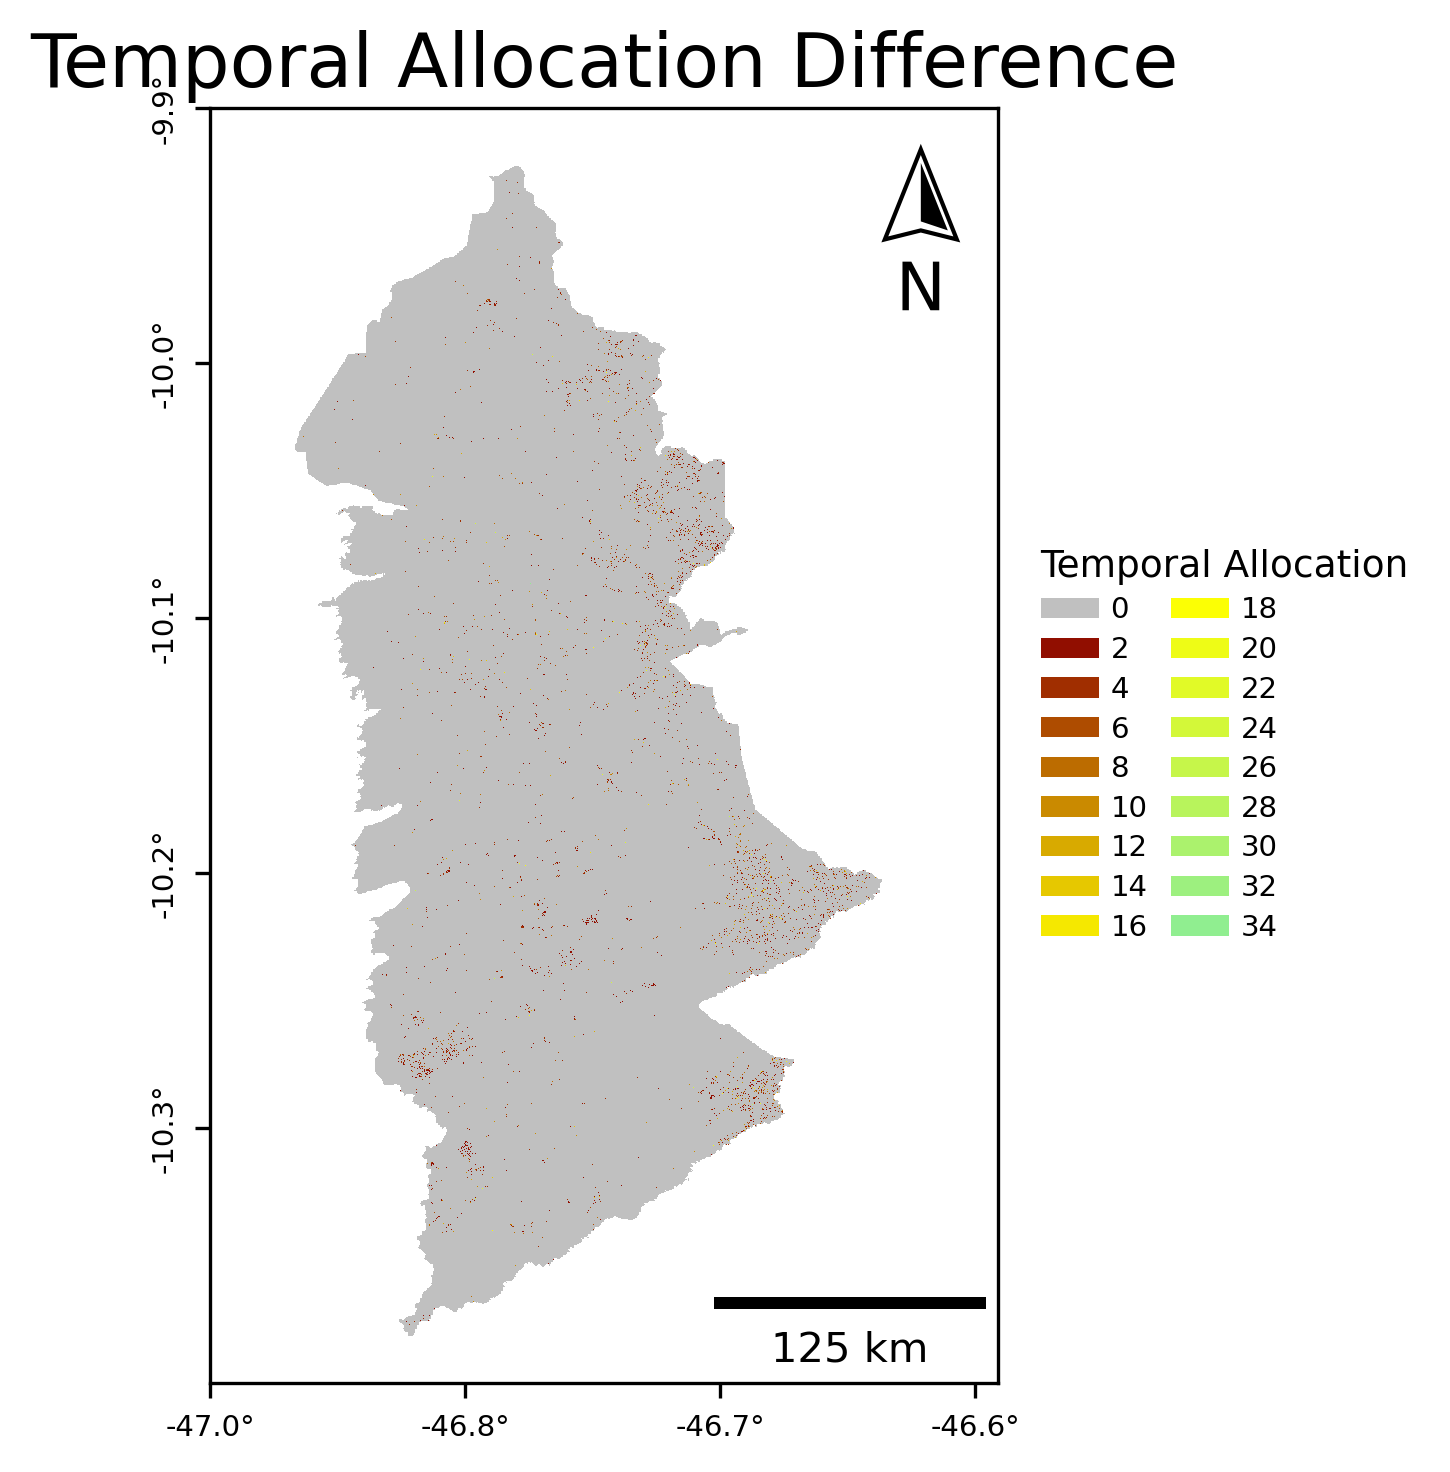

Map successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/maps/map_presence_temporal_allocation.png


In [71]:
# @title 6.5 Plot Temporal Allocation Difference for Presence
_plot_equation_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="eq51_presence_temporal_allocation.tif",
    title="Temporal Allocation Difference",
    legend_title="Temporal Allocation",
    output_png_name="map_presence_temporal_allocation.png",
    colormap_style="redyellowgreen",
)


Reading Change Hits map for plotting: /Users/antoniofonseca/Assessments/compare_ts/savanna/rasters/eq52_change_hit.tif
Loading raster with downsampling factor: 0.10


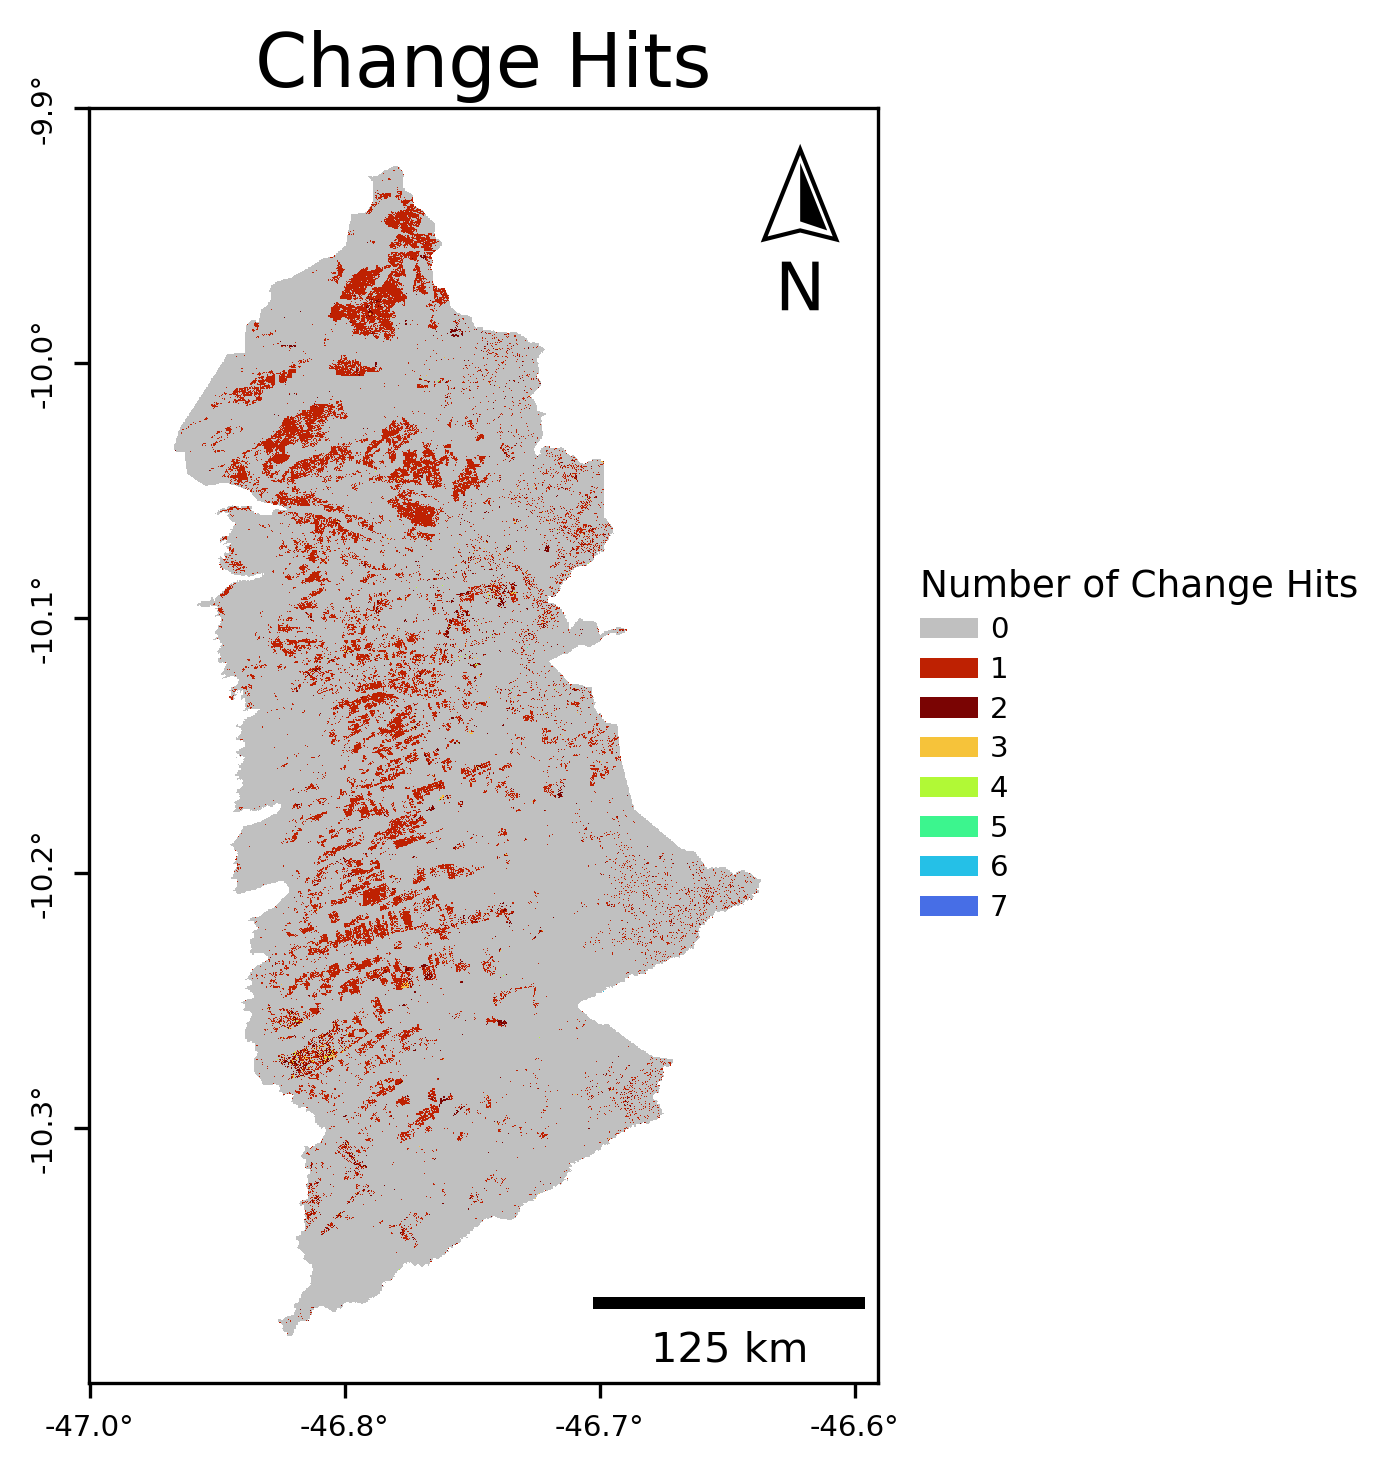

Map successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/maps/map_change_hits.png


In [67]:
# @title 6.6 Plot Change Hits
_plot_equation_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="eq52_change_hit.tif",
    title="Change Hits",
    legend_title="Number of Change Hits",
    output_png_name="map_change_hits.png",
    colormap_style="turbo_neg_black",
)


Reading Change Difference map for plotting: /Users/antoniofonseca/Assessments/compare_ts/savanna/rasters/eq53_change_difference.tif
Loading raster with downsampling factor: 0.10


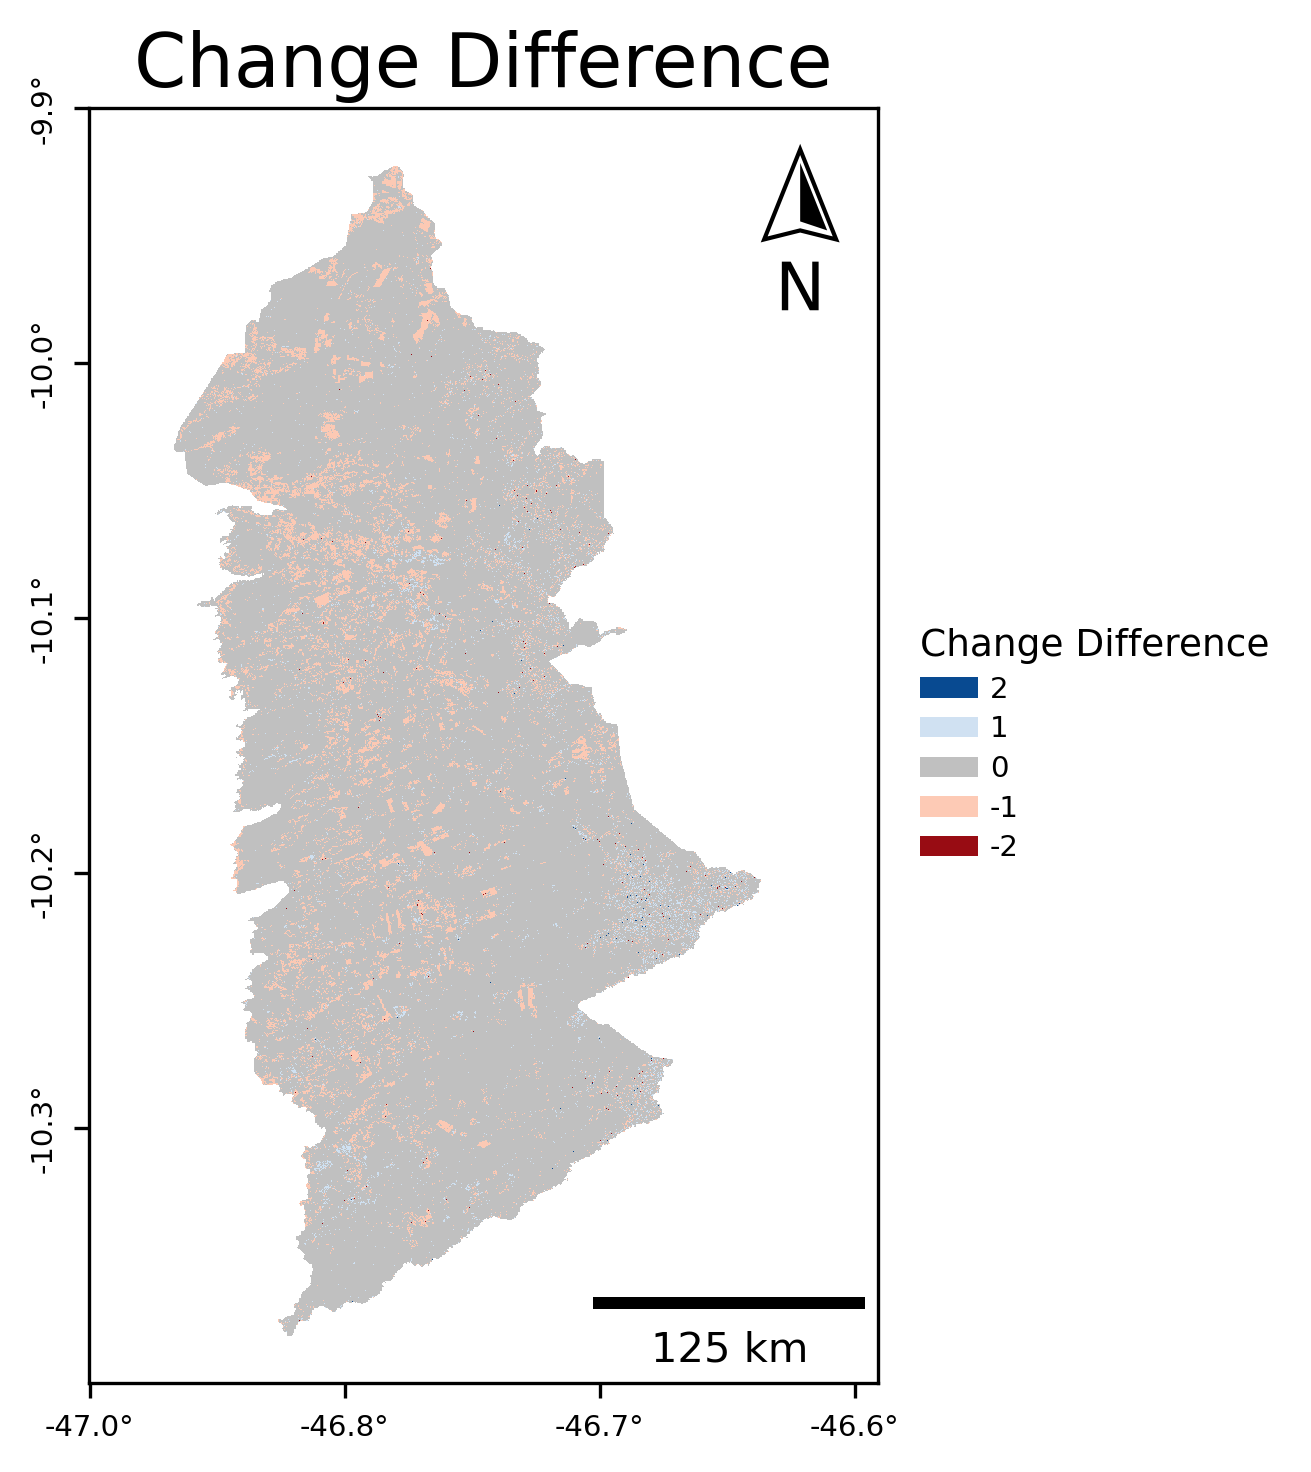

Map successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/maps/map_change_difference.png


In [68]:
# @title 6.7 Plot Change Difference
_plot_equation_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="eq53_change_difference.tif",
    title="Change Difference",
    legend_title="Change Difference",
    output_png_name="map_change_difference.png",
    colormap_style="diverging_redblue",
)


Reading Change Absolute Difference map for plotting: /Users/antoniofonseca/Assessments/compare_ts/savanna/rasters/eq54_change_temporal_allocation.tif
Loading raster with downsampling factor: 0.10


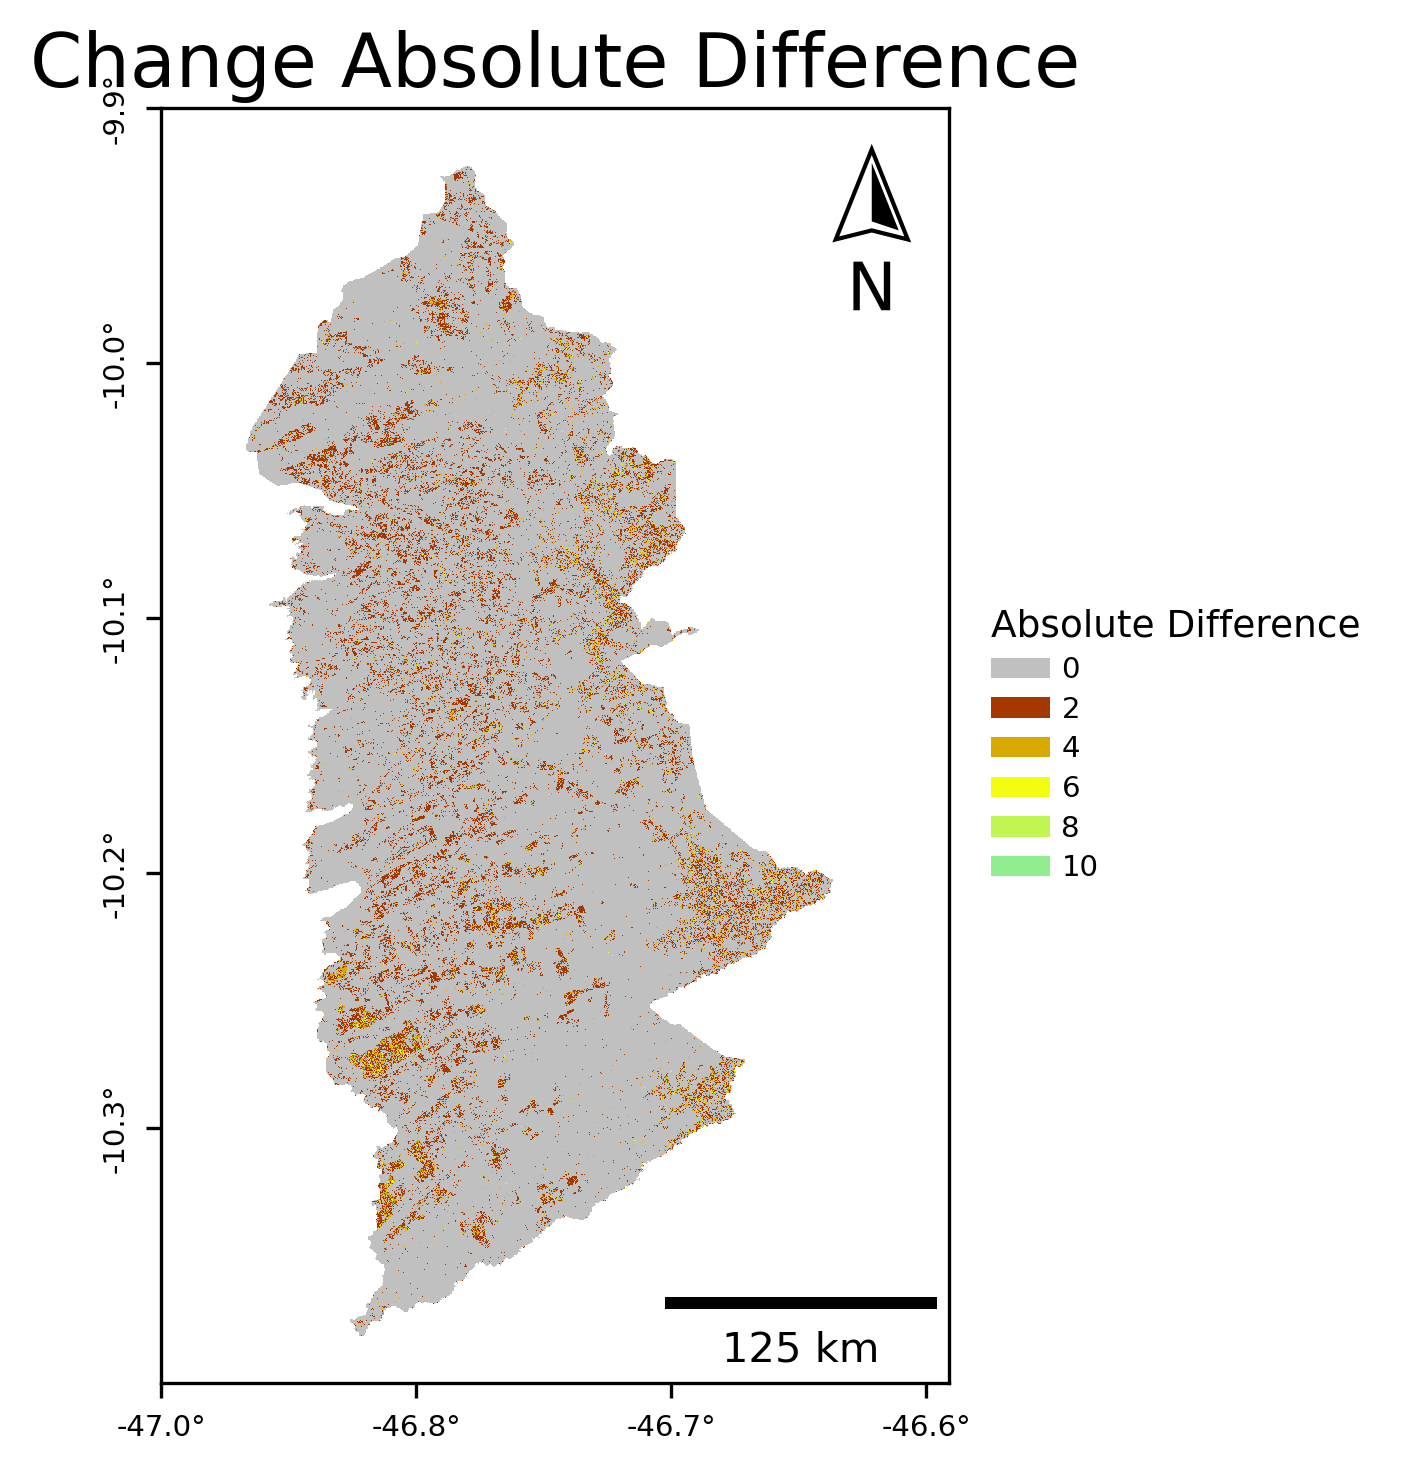

Map successfully saved to: /Users/antoniofonseca/Assessments/compare_ts/savanna/maps/map_change_absolute_difference.png


In [69]:
# @title 6.8 Plot Change Absolute Difference
_plot_equation_map(
    output_dir=output_path,
    nodata_val=no_data_value,
    raster_filename="eq54_change_temporal_allocation.tif",
    title="Change Absolute Difference",
    legend_title="Absolute Difference",
    output_png_name="map_change_absolute_difference.png",
    colormap_style="redyellowgreen",
)
